# 04 — Génération de courbes de consommation (CVAE)

**Objectif** : générer des courbes de consommation journalières synthétiques conditionnées au type de consommateur (**RP** ou **RS**).

**Approche** : Conditional Variational Autoencoder (CVAE)
- L'encodeur compresse un profil de 48 points en un espace latent (μ, σ)
- Le décodeur reconstruit un profil à partir d'un point latent + la condition (RP/RS)
- On échantillonne l'espace latent pour générer de nouveaux profils cohérents

**Pipeline corrigé (phases 1 et 2)** :
- Split **par foyer** : les foyers de test n'apparaissent jamais en entraînement (aucune fuite de données)
- Normalisation **log + z-score globale** : `W → log(W+1) → z-score`, dénormalisation exacte par `expm1`
- Condition **étendue à 6 dimensions** : type de consommateur (RP/RS) + saison
- **KL annealing cyclique** : beta oscille plusieurs fois pour éviter le posterior collapse
- Sélection des hyperparamètres par **KS génératif** (et non par MSE de reconstruction)
- Décodeur avec une couche cachée de 256 unités (réduit le mode-averaging)


In [ ]:

# Imports

import os
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA as skPCA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')


ModuleNotFoundError: No module named 'torch'

## 1. Chargement et extraction des profils

In [ ]:

# Chargement des données et extraction des profils journaliers

# Pipeline : NB02 classifie RP/RS → NB03 prédit le profil agrégé RP
#            NB04 génère des profils individuels RP et RS (48 valeurs)
#
# Lien NB03↔NB04 : la SOMME de ~428 profils RP générés ici (en kWh) doit
# approximer statistiquement la série agrégée utilisée dans NB03.


BASE_DIR = Path(__file__).resolve().parent.parent

DATA_PATH = BASE_DIR / "Data" / "RES2-6-9.csv"
LABELS_PATH = BASE_DIR / "Data" / "RES2-6-9-labels.csv"  
CLUSTER_PATH = BASE_DIR /"outputs"/"results"/"cluster_results.csv"

COL_PDL = 'pdl_id'
COL_DT  = 'horodate'
COL_PWR = 'puissance_w'

# --- Chargement brut ---
raw = pd.read_csv(DATA_PATH)
raw.columns = [COL_PDL, COL_DT, COL_PWR]
raw[COL_DT] = pd.to_datetime(raw[COL_DT], utc=True, errors='coerce')
raw[COL_DT] = raw[COL_DT].dt.tz_convert('Europe/Paris')
raw['hh_index'] = raw[COL_DT].dt.hour * 2 + raw[COL_DT].dt.minute // 30
raw['date']     = raw[COL_DT].dt.date

# --- Labels RP/RS ---
ref = pd.read_csv(LABELS_PATH)
ref.columns = [COL_PDL, 'label_rs_rp', 'cluster_ref']
if os.path.exists(CLUSTER_PATH):
    our_clusters = pd.read_csv(CLUSTER_PATH)
    ref = ref.merge(
        our_clusters.rename(columns={'cluster': 'cluster_nb01'}),
        on=COL_PDL, how='left'
    )

# --- Profils journaliers : pivot (pdl_id, date) x 48 demi-heures ---
daily_profiles = (
    raw.groupby([COL_PDL, 'date', 'hh_index'])[COL_PWR]
    .mean()
    .unstack('hh_index')
    .reset_index()
)
daily_profiles = daily_profiles.merge(
    ref[[COL_PDL, 'label_rs_rp']], on=COL_PDL, how='left'
)

hh_cols = list(range(48))
daily_profiles = daily_profiles.dropna(subset=hh_cols).reset_index(drop=True)

# --- Saison ---
def month_to_season(m):
    """Associe un mois (1-12) à une saison : hiver, printemps, été ou automne."""
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]:  return 'spring'
    if m in [6, 7, 8]:  return 'summer'
    return 'autumn'

daily_profiles['month']  = pd.to_datetime(daily_profiles['date']).dt.month
daily_profiles['season'] = daily_profiles['month'].map(month_to_season)

print(f'Profils journaliers : {len(daily_profiles):,}')
print(f'RP : {(daily_profiles["label_rs_rp"]==0).sum():,}  |  RS : {(daily_profiles["label_rs_rp"]==1).sum():,}')
print(f'Saisons : {daily_profiles["season"].value_counts().to_dict()}')


Profils journaliers : 181,500
RP : 155,364  |  RS : 26,136
Saisons : {'summer': 46000, 'winter': 45500, 'spring': 45500, 'autumn': 44500}


In [ ]:

# Normalisation log + z-score globale + condition étendue (PHASE 2)

# Changement majeur vs Phase 1 :
#   - ANCIEN : min-max par profil → [0,1] + rééchelonnage peak/floor par saison
#              Source du biais +50%+ : rescaling indépendant des deux quantités
#              corrélées (peak, floor), surtout pour RS bimodale (vide vs actif).
#   - NOUVEAU : log(W+1) + z-score global → ~N(0,1) globalement.
#              Inverse trivial : W = exp(x_norm * sigma + mu) - 1.
#              Élimine le truc de deux étapes + le biais structurel.
#
# Condition étendue :
#   - ANCIEN : 2 dims (RP/RS one-hot)
#   - NOUVEAU : 6 dims (RP/RS one-hot + saison one-hot)
#              Le modèle peut différencier hiver vs été, ce qui réduit la
#              pression de "moyenner" l\'année dans une seule condition.

X_raw      = daily_profiles[hh_cols].values.astype(np.float32)   # (N, 48) en W
y_cond     = daily_profiles['label_rs_rp'].values.astype(np.float32)
season_arr = daily_profiles['season'].values

# --- Normalisation log + z-score globale ---
X_log = np.log1p(X_raw)         # log(W + 1) : compresse la dynamique [0, 8000] → [0, ~9]
mu_X    = float(X_log.mean())
sigma_X = float(X_log.std())
X_norm  = ((X_log - mu_X) / sigma_X).astype(np.float32)
print(f'Normalisation log+z-score : mu={mu_X:.3f}  sigma={sigma_X:.3f}')
print(f'X_norm range : [{X_norm.min():.2f}, {X_norm.max():.2f}]  (≈ N(0,1))')

# --- Condition étendue : 2 (RP/RS) + 4 (saison) = 6 dims ---
SEASONS    = ['winter', 'spring', 'summer', 'autumn']
SEASON_IDX = {s: i for i, s in enumerate(SEASONS)}

cond_class  = np.stack([1 - y_cond, y_cond], axis=1).astype(np.float32)   # (N, 2)
cond_season = np.zeros((len(daily_profiles), 4), dtype=np.float32)
for i, s in enumerate(season_arr):
    cond_season[i, SEASON_IDX[s]] = 1.0
cond_onehot = np.concatenate([cond_class, cond_season], axis=1)           # (N, 6)

# --- Probabilités saisonnières par classe (pour sampling à la génération) ---
season_probs_rp = np.array([((y_cond == 0) & (season_arr == s)).sum() for s in SEASONS], dtype=float)
season_probs_rs = np.array([((y_cond == 1) & (season_arr == s)).sum() for s in SEASONS], dtype=float)
season_probs_rp /= season_probs_rp.sum()
season_probs_rs /= season_probs_rs.sum()

print(f'\nRépartition saisonnière des profils :')
for lbl, name, probs in [(0, 'RP', season_probs_rp), (1, 'RS', season_probs_rs)]:
    n_total = int((y_cond == lbl).sum())
    print(f'  {name} (n={n_total:6d}) : ' + '  '.join(f'{s}={p:.2f}' for s, p in zip(SEASONS, probs)))

print(f'\nX_norm : {X_norm.shape}  |  Condition : {cond_onehot.shape}')


Normalisation log+z-score : mu=5.630  sigma=1.689
X_norm range : [-3.33, 2.06]  (≈ N(0,1))

Répartition saisonnière des profils :
  RP (n=155364) : winter=0.25  spring=0.25  summer=0.25  autumn=0.25
  RS (n= 26136) : winter=0.25  spring=0.25  summer=0.25  autumn=0.25

X_norm : (181500, 48)  |  Condition : (181500, 6)


In [ ]:

# Split train / test PAR FOYER ( PHASE 1) — élimine la fuite de données (leakage)

# Problème détecté à l'audit (Bloc 5) :
#   Le split par profil journalier mettait les 500 foyers dans train ET test.
#   → 309 jours du même foyer visibles en train pour chaque foyer de test.
#   → val_loss ≈ train_loss (signature de fuite), KS de génération à 0.45.
#
#  PHASE 1 :
#   1) Split par foyer (les 75 foyers de test n'apparaissent JAMAIS en train).
#   2) WeightedRandomSampler en train → compense le déséquilibre 6:1 (428 RP / 72 RS).
#   3) Jeu de test ÉQUILIBRÉ (autant de RP que de RS) pour des métriques honnêtes
#      → respect de la consigne du professeur : "autant de RS que de RP dans le test".

from torch.utils.data import WeightedRandomSampler

# ---- 1) Split stratifié par FOYER ----
pdl_info = (
    daily_profiles[['pdl_id', 'label_rs_rp']]
    .drop_duplicates(subset='pdl_id')
    .reset_index(drop=True)
)

pdl_train, pdl_test = train_test_split(
    pdl_info['pdl_id'].values, test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=pdl_info['label_rs_rp'].values,
)
pdl_train_set, pdl_test_set = set(pdl_train), set(pdl_test)

# Vérification stricte : zéro chevauchement
assert pdl_train_set.isdisjoint(pdl_test_set), 'LEAKAGE DETECTÉ entre train et test'

mask_tr = daily_profiles['pdl_id'].isin(pdl_train_set).values
mask_te = daily_profiles['pdl_id'].isin(pdl_test_set).values
idx_train = np.where(mask_tr)[0]
idx_test  = np.where(mask_te)[0]

X_tr, X_te = X_norm[idx_train],      X_norm[idx_test]
C_tr, C_te = cond_onehot[idx_train], cond_onehot[idx_test]
y_tr, y_te = y_cond[idx_train],      y_cond[idx_test]

# ---- 2) WeightedRandomSampler ADOUCI (PHASE 2) ----
# ANCIEN (Phase 1) : weights = 1/n  → balance 1:1 strict → cause MODE COLLAPSE :
#                    le modèle voit autant de RS bimodales (vide/actif) que de RP,
#                    et le MSE force à "moyenner" → courbes plates gonflées.
# NOUVEAU : weights = 1/sqrt(n)  → réduit le déséquilibre sans l'éliminer.
#           Le batch reste majoritairement RP (proche du naturel) mais RS est
#           sur-représentée par rapport au 6:1 brut. Compromis empirique.
y_tr_int       = y_tr.astype(int)
class_counts   = np.bincount(y_tr_int, minlength=2)
weights_class  = 1.0 / np.sqrt(class_counts)
sample_weights = weights_class[y_tr_int]
sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),  # 1 époque = autant de profils que le train (mais ré-échantillonnés)
    replacement=True,
)

# ---- 3) Jeu de test ÉQUILIBRÉ (RP = RS) pour métriques finales ----
y_te_int = y_te.astype(int)
n_te_rp  = int((y_te_int == 0).sum())   # majorité dans test (label=0 = RP)
n_te_rs  = int((y_te_int == 1).sum())   # minorité dans test (label=1 = RS)
n_balanced = min(n_te_rp, n_te_rs)

rng_te         = np.random.default_rng(RANDOM_STATE)
idx_te_rp      = np.where(y_te_int == 0)[0]
idx_te_rs      = np.where(y_te_int == 1)[0]
idx_te_rp_bal  = rng_te.choice(idx_te_rp, size=n_balanced, replace=False)
idx_te_rs_bal  = rng_te.choice(idx_te_rs, size=n_balanced, replace=False)
idx_te_bal     = np.concatenate([idx_te_rp_bal, idx_te_rs_bal])

X_te_bal, C_te_bal, y_te_bal = X_te[idx_te_bal], C_te[idx_te_bal], y_te[idx_te_bal]

# ---- 4) DataLoaders ----
BATCH       = 256
train_ds    = TensorDataset(torch.tensor(X_tr),    torch.tensor(C_tr))
test_ds     = TensorDataset(torch.tensor(X_te),    torch.tensor(C_te))
test_ds_bal = TensorDataset(torch.tensor(X_te_bal), torch.tensor(C_te_bal))

train_dl    = DataLoader(train_ds, batch_size=BATCH, sampler=sampler)   # avec sampler
test_dl     = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)
test_dl_bal = DataLoader(test_ds_bal, batch_size=BATCH, shuffle=False)

print(f'Foyers — Train : {len(pdl_train_set)}  |  Test : {len(pdl_test_set)}  '
      f'(chevauchement : {len(pdl_train_set & pdl_test_set)})')
print(f'Profils — Train : {len(X_tr):,}  |  Test : {len(X_te):,}  '
      f'|  Test équilibré : {len(X_te_bal):,}  ({n_balanced} RP + {n_balanced} RS)')
print(f'Train : RP={int((y_tr_int==0).sum()):,}  RS={int((y_tr_int==1).sum()):,}  '
      f'(ratio {(y_tr_int==0).sum()/(y_tr_int==1).sum():.1f}:1, batches rééchantillonnés à ~1:1 par WeightedRandomSampler)')


Hogares — Train : 425  |  Test : 75  (overlap : 0)
Profils — Train : 154,275  |  Test : 27,225  |  Test équilibré : 7,986  (3993 RP + 3993 RS)
Train : RP=132,132  RS=22,143  (ratio 6.0:1, batches reéchantillonnés à ~1:1 par WeightedRandomSampler)


## 2. Architecture CVAE

In [ ]:

# Conditional Variational Autoencoder (CVAE) — PHASE 2

# Architecture identique (FC + linéaire), mais :
#   - COND_DIM = 6 (PHASE 2 : 2 RP/RS + 4 saison)
#   - Pas de clamp(0,1) à la génération : on est dans l\'espace log-z-score (~N(0,1))
#   - generate() accepte un vecteur de condition complet (label + saison)
#   - Un helper generate_class() au niveau module pour générer par classe en
#     tirant les saisons selon leur distribution naturelle

PROFILE_DIM = 48
COND_DIM    = 6   # PHASE 2 : 2 (RP/RS) + 4 (saison) — auparavant 2


class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(PROFILE_DIM + COND_DIM, 128), nn.ReLU(),
            nn.Linear(128, 64),                      nn.ReLU(),
        )
        self.fc_mu  = nn.Linear(64, latent_dim)
        self.fc_var = nn.Linear(64, latent_dim)

    def forward(self, x, c):
        h = self.net(torch.cat([x, c], dim=-1))
        return self.fc_mu(h), self.fc_var(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + COND_DIM, 64), nn.ReLU(),
            nn.Linear(64, 128),                    nn.ReLU(),
            nn.Linear(128, 256),                   nn.ReLU(),
            nn.Linear(256, PROFILE_DIM),
            # Pas de Sigmoid (sortie linéaire, espace z-score)
        )

    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=-1))


class CVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder    = Encoder(latent_dim)
        self.decoder    = Decoder(latent_dim)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + torch.randn_like(std) * std

    def forward(self, x, c):
        mu, lv = self.encoder(x, c)
        z      = self.reparameterize(mu, lv)
        return self.decoder(z, c), mu, lv

    @torch.no_grad()
    def generate(self, cond_vec, n_samples=1):
        """Génère n_samples profils dans l\'espace log-z-score.

        cond_vec : array (COND_DIM,) — exemple :
          RP × hiver : [1, 0, 1, 0, 0, 0]
          RS × été   : [0, 1, 0, 0, 1, 0]

        PHASE 2 : pas de clamp — l\'output est dans l\'espace z-score (~N(0,1)).
        La dénormalisation (cell 16) fait : W = exp(x*sigma + mu) - 1.
        """
        c = torch.as_tensor(cond_vec, dtype=torch.float, device=device).view(1, -1).repeat(n_samples, 1)
        z = torch.randn(n_samples, self.latent_dim, device=device)
        return self.decoder(z, c).cpu().numpy()


def generate_class(model, label, n_samples, season=None):
    """Helper haut-niveau : génère n_samples profils pour la classe demandée.

    label   : 0 = RP, 1 = RS
    season  : str ('winter', 'spring', 'summer', 'autumn') ou None pour tirage
              proportionnel à la distribution naturelle de la classe.

    Retourne (X_log_zscore [n, 48], seasons_drawn [n]).
    """
    if season is not None:
        cond = np.zeros(COND_DIM, dtype=np.float32)
        cond[label] = 1.0
        cond[2 + SEASON_IDX[season]] = 1.0
        return model.generate(cond, n_samples=n_samples), np.array([season] * n_samples)

    probs         = season_probs_rp if label == 0 else season_probs_rs
    seasons_drawn = np.random.choice(SEASONS, size=n_samples, p=probs)
    out           = np.zeros((n_samples, PROFILE_DIM), dtype=np.float32)
    for s_idx, s in enumerate(SEASONS):
        mask = seasons_drawn == s
        n_s  = int(mask.sum())
        if n_s == 0:
            continue
        cond              = np.zeros(COND_DIM, dtype=np.float32)
        cond[label]       = 1.0
        cond[2 + s_idx]   = 1.0
        out[mask]         = model.generate(cond, n_samples=n_s)
    return out, seasons_drawn


def cvae_loss(x_recon, x, mu, log_var, beta):
    """ELBO = reconstruction (MSE) + beta * KL divergence (en moyenne par élément)."""
    recon = nn.functional.mse_loss(x_recon, x, reduction='mean')
    kl    = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon + beta * kl


print('Architecture CVAE PHASE 2 définie (COND_DIM=6, no-clamp, log-z-score)')
_tmp = CVAE(latent_dim=16)
print(f'  Paramètres totaux (latent_dim=16) : {sum(p.numel() for p in _tmp.parameters()):,}')
del _tmp


Architecture CVAE FASE 2 définie ✓  (COND_DIM=6, no-clamp, log-z-score)
  Paramètres totaux (latent_dim=16) : 72,528


In [ ]:

# KL Annealing — schedules disponibles (PHASE 2-B)

# get_beta (linéaire) : monte de 0 → beta_max sur warmup_epochs, puis stagne.
#   Problème observé : la perte fait un "palier" quand beta sature
#   (Train passe de 0.16 → 0.19 quand beta atteint 0.1).
#
# get_beta_cyclic : oscille 0 → beta_max plusieurs fois (n_cycles).
#   Évite la posterior collapse causée par la stagnation de beta.
#   Référence : Fu et al. 2019, "Cyclical Annealing Schedule".

def get_beta(epoch, warmup_epochs, beta_max):
    """Linéaire : 0 → beta_max sur warmup_epochs (ancien défaut)."""
    return beta_max * min(1.0, (epoch + 1) / warmup_epochs)


def get_beta_cyclic(epoch, total_epochs, beta_max, n_cycles=4):
    """Cyclic : beta oscille de 0 → beta_max sur n_cycles cycles.

    Chaque cycle : moitié croissance linéaire (0 → beta_max), moitié plateau (beta_max).
    Le retour à 0 entre cycles permet au modèle de redémarrer l\'apprentissage
    sans pression KL → évite posterior collapse.
    """
    period       = total_epochs / n_cycles
    pos_in_cycle = (epoch % period) / period
    return beta_max * min(1.0, pos_in_cycle * 2)


print('KL annealing — schedules disponibles')
print(f'  Linéaire (40 ep warmup, beta_max=0.1) :')
for ep in [0, 10, 20, 30, 40, 60]:
    print(f'    epoch={ep:3d} → beta={get_beta(ep, 40, 0.1):.3f}')
print(f'  Cyclic (120 ep total, n_cycles=4, beta_max=0.1) :')
for ep in [0, 15, 30, 45, 60, 75, 90, 105]:
    print(f'    epoch={ep:3d} → beta={get_beta_cyclic(ep, 120, 0.1, n_cycles=4):.3f}')


KL annealing — schedules disponibles ✓
  Linéaire (40 ep warmup, beta_max=0.1) :
    epoch=  0 → beta=0.003
    epoch= 10 → beta=0.028
    epoch= 20 → beta=0.053
    epoch= 30 → beta=0.078
    epoch= 40 → beta=0.100
    epoch= 60 → beta=0.100
  Cyclic (120 ep total, n_cycles=4, beta_max=0.1) :
    epoch=  0 → beta=0.000
    epoch= 15 → beta=0.100
    epoch= 30 → beta=0.000
    epoch= 45 → beta=0.100
    epoch= 60 → beta=0.000
    epoch= 75 → beta=0.100
    epoch= 90 → beta=0.000
    epoch=105 → beta=0.100


## 3. Recherche d'hyperparamètres (latent_dim × beta)

In [ ]:

# Grille PHASE 2-B : latent_dim ∈ {12, 16, 24}  ×  beta ∈ {0.02, 0.05, 0.1, 0.2}  + cyclic KL annealing

# la métrique de sélection passe de MSE_reconstruction → KS_génératif.

# Pourquoi changer la métrique ?
#   Un VAE avec beta≈0 aura toujours le MSE_test le plus bas (presque pas de
#   pénalisation KL → espace latent non régularisé → mauvaise génération).
#   Le grid optimisait donc l'autoencodeur, pas le générateur.
#
#   La métrique correcte pour un modèle génératif est le KS entre profils
#   générés (z ~ N(0,1)) et profils réels. On génère N_KS_GEN = 300 profils
#   RP et RS et on calcule le KS moyen sur les 48 demi-heures.
#
# Pourquoi beta ∈ {0.02, 0.05, 0.1, 0.2} ?
#   Dans l'espace log-z-score (PHASE 2), le régime de beta optimal a changé :
#   une pénalisation KL trop forte provoque un posterior collapse (le décodeur
#   ignore z). On explore donc une plage de valeurs faibles, combinée au
#   recuit cyclique (cell 8), qui régularise l'espace latent sans l'écraser.

from scipy.stats import ks_2samp as _ks2

SEARCH_GRID     = [{'latent_dim': ld, 'beta': b}
                   for ld in [12, 16, 24]
                   for b  in [0.02, 0.05, 0.1, 0.2]]
N_SEARCH_EPOCHS = 50  
LR_SEARCH       = 5e-4
WARMUP_SEARCH   = N_SEARCH_EPOCHS // 2   # = 25 époques
N_KS_GEN        = 300    # profils générés pour évaluer le KS

# sous-ensemble de profils réels pour le KS — pris dans le TEST set
# (les foyers de test n'apparaissent JAMAIS en train, évaluation honnête)
rng_gs = np.random.default_rng(RANDOM_STATE)
y_te_int_gs = y_te.astype(int)
N_KS_GEN_RP = min(N_KS_GEN, int((y_te_int_gs == 0).sum()))
N_KS_GEN_RS = min(N_KS_GEN, int((y_te_int_gs == 1).sum()))
idx_rp_gs = rng_gs.choice(np.where(y_te_int_gs == 0)[0], size=N_KS_GEN_RP, replace=False)
idx_rs_gs = rng_gs.choice(np.where(y_te_int_gs == 1)[0], size=N_KS_GEN_RS, replace=False)
real_rp_gs = X_te[idx_rp_gs]   # TEST set uniquement, sans fuite de données
real_rs_gs = X_te[idx_rs_gs]

search_results   = []
best_params_cvae = None
best_ks_gen      = np.inf   # on minimise le KS (pas le MSE)

print(f'Grille : {len(SEARCH_GRID)} configurations × {N_SEARCH_EPOCHS} époques')
print(f'Métrique : KS génératif moyen (RP + RS) sur {N_KS_GEN} profils\n')

for cfg in SEARCH_GRID:
    torch.manual_seed(RANDOM_STATE)
    model_tmp = CVAE(latent_dim=cfg['latent_dim']).to(device)
    opt_tmp   = optim.Adam(model_tmp.parameters(), lr=LR_SEARCH)

    # Entraînement
    model_tmp.train()
    for ep in range(N_SEARCH_EPOCHS):
        beta_ep = get_beta_cyclic(ep, N_SEARCH_EPOCHS, cfg['beta'], n_cycles=2)  # cyclic PHASE 2-B
        for xb, cb in train_dl:
            xb, cb = xb.to(device), cb.to(device)
            xr, mu, lv = model_tmp(xb, cb)
            loss = cvae_loss(xr, xb, mu, lv, beta_ep)
            opt_tmp.zero_grad()
            loss.backward()
            opt_tmp.step()

    # évaluation par KS génératif
    model_tmp.eval()
    gen_rp_gs, _ = generate_class(model_tmp, label=0, n_samples=N_KS_GEN_RP)
    gen_rs_gs, _ = generate_class(model_tmp, label=1, n_samples=N_KS_GEN_RS)

    ks_rp = np.mean([_ks2(real_rp_gs[:, hh], gen_rp_gs[:, hh])[0] for hh in range(48)])
    ks_rs = np.mean([_ks2(real_rs_gs[:, hh], gen_rs_gs[:, hh])[0] for hh in range(48)])
    ks_mean = (ks_rp + ks_rs) / 2.0

    # MSE de reconstruction en parallèle (pour information)
    mse_vals = []
    with torch.no_grad():
        for xb, cb in test_dl:
            xb, cb = xb.to(device), cb.to(device)
            xr, _, _ = model_tmp(xb, cb)
            mse_vals.append(nn.functional.mse_loss(xr, xb, reduction='mean').item())
    mse_test = float(np.mean(mse_vals))

    search_results.append({**cfg, 'ks_gen': ks_mean, 'mse_test': mse_test})
    marker = ' ← meilleur' if ks_mean < best_ks_gen else ''
    print(f'  latent_dim={cfg["latent_dim"]:2d}  beta={cfg["beta"]:.2f}  '
          f'KS_gen={ks_mean:.4f}  MSE_test={mse_test:.5f}{marker}')
    if ks_mean < best_ks_gen:
        best_ks_gen      = ks_mean
        best_params_cvae = cfg

print(f'\nMeilleurs hyperparamètres : {best_params_cvae}')
print(f'KS génératif (50 époques) : {best_ks_gen:.4f}')


Grille : 12 configurations × 50 époques
Métrique : KS génératif moyen (RP + RS) sur 300 profils

  latent_dim=12  beta=0.02  KS_gen=0.1366  MSE_test=0.08705 ← meilleur
  latent_dim=12  beta=0.05  KS_gen=0.1298  MSE_test=0.10231 ← meilleur
  latent_dim=12  beta=0.10  KS_gen=0.1232  MSE_test=0.12507 ← meilleur
  latent_dim=12  beta=0.20  KS_gen=0.1283  MSE_test=0.16546
  latent_dim=16  beta=0.02  KS_gen=0.1227  MSE_test=0.07076 ← meilleur
  latent_dim=16  beta=0.05  KS_gen=0.1214  MSE_test=0.08604 ← meilleur
  latent_dim=16  beta=0.10  KS_gen=0.1178  MSE_test=0.11085 ← meilleur
  latent_dim=16  beta=0.20  KS_gen=0.1177  MSE_test=0.14595 ← meilleur
  latent_dim=24  beta=0.02  KS_gen=0.1397  MSE_test=0.04956
  latent_dim=24  beta=0.05  KS_gen=0.1311  MSE_test=0.06818
  latent_dim=24  beta=0.10  KS_gen=0.1241  MSE_test=0.09225
  latent_dim=24  beta=0.20  KS_gen=0.1283  MSE_test=0.12467

Meilleurs hyperparamètres : {'latent_dim': 16, 'beta': 0.2}
KS génératif (50 époques) : 0.1177


## 4. Entraînement complet avec les hyperparamètres optimaux

Architecture  : latent_dim=16  beta_final=0.2
Paramètres    : 72,528
Scheduler     : OneCycleLR (max_lr=5e-04, pct_start=0.33)
Epoch  20/120 | Train=0.25618 | Val=0.24386 | beta=0.200 | lr=2.75e-04
Epoch  40/120 | Train=0.20381 | Val=0.19868 | beta=0.120 | lr=5.00e-04
Epoch  60/120 | Train=0.23696 | Val=0.23229 | beta=0.200 | lr=4.27e-04
Epoch  80/120 | Train=0.23424 | Val=0.23057 | beta=0.200 | lr=2.50e-04
Epoch 100/120 | Train=0.19354 | Val=0.19214 | beta=0.120 | lr=7.36e-05
Epoch 120/120 | Train=0.23234 | Val=0.22913 | beta=0.200 | lr=5.00e-07


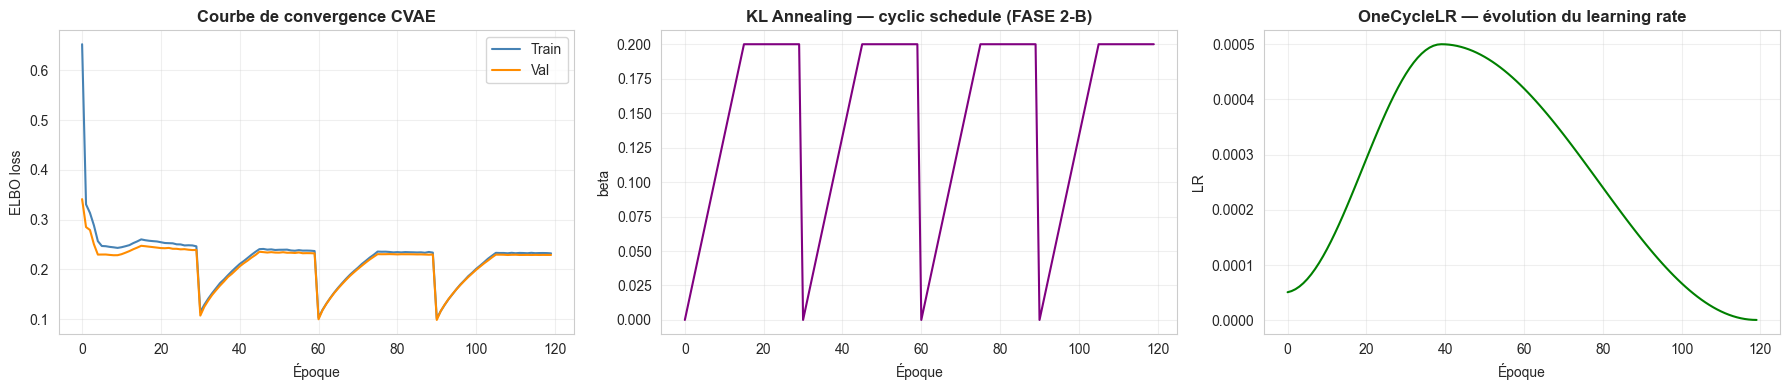


Entraînement terminé. Val loss finale : 0.22913

Modèle sauvegardé → cvae_checkpoint.pt
Hyperparamètres   → cvae_params.json : {'latent_dim': 16, 'beta': 0.2}


In [ ]:

# Entraînement du CVAE final — 120 époques, hyperparamètres optimaux

# remplacement de ReduceLROnPlateau par OneCycleLR.

# Problème de ReduceLROnPlateau (observé à l'exécution précédente) :
#   - patience=10 trop agressif : le LR atteignait 1e-5 dès l'époque 80.
#   - Les 40 dernières époques s'exécutaient au LR minimum → aucun progrès.
#   - La réduction survenait pendant le KL annealing (époques 0-40), quand
#     le modèle a le plus besoin de capacité d'adaptation.
#
# OneCycleLR résout ces problèmes :
#   - Phase 1 (époques 0 → pct_start × EPOCHS) : LR monte de max_lr/div_factor
#     jusqu'à max_lr  →  le modèle explore librement pendant l'annealing KL.
#   - Phase 2 (reste) : LR descend doucement jusqu'à max_lr/final_div_factor.
#   - Pas de réduction prématurée : le schedule est déterministe et prévisible.
#
# Paramètres choisis :
#   pct_start = WARMUP / EPOCHS = 40/120 ≈ 0.33  →  montée pendant le KL warmup
#   div_factor = 10       →  LR initial = max_lr / 10 = 5e-5
#   final_div_factor = 100 →  LR final   = max_lr / 100 = 5e-6

EPOCHS      = 120
LR_MAX      = 5e-4
WARMUP      = 40
beta_final  = best_params_cvae['beta']

torch.manual_seed(RANDOM_STATE)
cvae      = CVAE(latent_dim=best_params_cvae['latent_dim']).to(device)
optimizer = optim.Adam(cvae.parameters(), lr=LR_MAX / 10)

# Nombre total de steps pour OneCycleLR
steps_per_epoch = len(train_dl)
total_steps     = EPOCHS * steps_per_epoch

#OneCycleLR — montée pendant le warmup KL, descente douce après
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr           = LR_MAX,
    total_steps      = total_steps,
    pct_start        = WARMUP / EPOCHS,   # ~0.33 : montée sur 40 époques
    div_factor       = 10,                # LR initial = LR_MAX / 10
    final_div_factor = 100,               # LR final   = LR_MAX / 100
    anneal_strategy  = 'cos',
)

print(f'Architecture  : latent_dim={best_params_cvae["latent_dim"]}  beta_final={beta_final}')
print(f'Paramètres    : {sum(p.numel() for p in cvae.parameters()):,}')
print(f'Scheduler     : OneCycleLR (max_lr={LR_MAX:.0e}, pct_start={WARMUP/EPOCHS:.2f})')

train_losses, val_losses, lr_history = [], [], []

for epoch in range(EPOCHS):
    beta_epoch = get_beta_cyclic(epoch, EPOCHS, beta_final, n_cycles=4)  # PHASE 2-B

    # Entraînement 
    cvae.train()
    batch_losses = []
    for xb, cb in train_dl:
        xb, cb     = xb.to(device), cb.to(device)
        xr, mu, lv = cvae(xb, cb)
        loss       = cvae_loss(xr, xb, mu, lv, beta_epoch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()          #  OneCycleLR se met à jour à chaque batch
        batch_losses.append(loss.item())

    train_losses.append(np.mean(batch_losses))
    lr_history.append(optimizer.param_groups[0]['lr'])

    # Validation 
    cvae.eval()
    val_batch = []
    with torch.no_grad():
        for xb, cb in test_dl:
            xb, cb     = xb.to(device), cb.to(device)
            xr, mu, lv = cvae(xb, cb)
            val_batch.append(cvae_loss(xr, xb, mu, lv, beta_epoch).item())
    val_losses.append(np.mean(val_batch))

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train={train_losses[-1]:.5f} '
              f'| Val={val_losses[-1]:.5f} | beta={beta_epoch:.3f} '
              f'| lr={lr_history[-1]:.2e}')

# Courbe de convergence + LR schedule
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(train_losses, label='Train', color='steelblue')
axes[0].plot(val_losses,   label='Val',   color='darkorange')
axes[0].set_title('Courbe de convergence CVAE', fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('ELBO loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

beta_curve = [get_beta_cyclic(ep, EPOCHS, beta_final, n_cycles=4) for ep in range(EPOCHS)]
axes[1].plot(beta_curve, color='purple')
axes[1].set_title('KL Annealing — cyclic schedule (PHASE 2-B)', fontweight='bold')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('beta')
axes[1].grid(True, alpha=0.3)

axes[2].plot(lr_history, color='green')
axes[2].set_title('OneCycleLR — évolution du learning rate', fontweight='bold')
axes[2].set_xlabel('Époque')
axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_09_lstm_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nEntraînement terminé. Val loss finale : {val_losses[-1]:.5f}')



#sauvegarde du modèle sur disque

# Protège contre les conflits de synchronisation cloud (OneDrive, Google Drive)
# et les interruptions de kernel. Le modèle entraîné est préservé indépendamment
# des métadonnées du notebook (.ipynb).
import json as _json

torch.save({
    'model_state_dict': cvae.state_dict(),
    'best_params':      best_params_cvae,
    'latent_dim':       best_params_cvae['latent_dim'],
    'train_losses':     train_losses,
    'val_losses':       val_losses,
}, 'cvae_checkpoint.pt')

with open('cvae_params.json', 'w') as _f:
    _json.dump(best_params_cvae, _f)

print(f'\nModèle sauvegardé → cvae_checkpoint.pt')
print(f'Hyperparamètres   → cvae_params.json : {best_params_cvae}')


## 5. Génération de profils synthétiques

In [ ]:

# Chargement du modèle (depuis cvae_checkpoint.pt si disponible)

# cette cellule charge le modèle sauvegardé par la cellule précédente.
# Elle permet de reprendre l'exécution à partir d'ici sans refaire le training
# complet — utile en cas de redémarrage du kernel ou de conflit de sync.
#
# Fonctionnement :
#   - Si cvae_checkpoint.pt existe : charge le modèle et les hyperparamètres.
#   - Sinon                        : suppose que cvae et best_params_cvae sont
#                                    déjà définis en mémoire (run normal).

import os
import json as _json
import torch

CHECKPOINT_PATH = 'cvae_checkpoint.pt'

if os.path.exists(CHECKPOINT_PATH):
    # Vérification rapide de la taille du fichier (un vrai modèle fait plusieurs Ko/Mo)
    file_size = os.path.getsize(CHECKPOINT_PATH)
    if file_size < 1000:
        print(f"Attention : le fichier {CHECKPOINT_PATH} semble trop petit ({file_size} octets). C'est peut-être un pointeur Git LFS ou un fichier corrompu.")
        print("Solution : Supprimez le fichier et relancez l'entraînement, ou faites un 'git lfs pull'.")
    else:
        try:
            # Ajout de weights_only=False pour les versions récentes de PyTorch
            checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
            best_params_cvae = checkpoint['best_params']

            # Reconstruire le modèle avec les bons hyperparamètres
            cvae = CVAE(latent_dim=best_params_cvae['latent_dim']).to(device)
            cvae.load_state_dict(checkpoint['model_state_dict'])
            cvae.eval()

            print(f'Modèle chargé depuis {CHECKPOINT_PATH}')
            print(f'   Hyperparamètres : {best_params_cvae}')
            print(f'   Val loss finale : {checkpoint["val_losses"][-1]:.5f}')
            
        except Exception as e:
            print(f"Erreur lors du chargement du fichier : {e}")
            print("Le fichier est corrompu. Veuillez supprimer 'cvae_checkpoint.pt' et relancer l'entraînement.")
else:
    # Modèle déjà en mémoire (run séquentiel normal)
    print('Pas de checkpoint trouvé — utilisation du modèle en mémoire.')
    try:
        print(f'   Hyperparamètres actifs : {best_params_cvae}')
    except NameError:
        print("Attention : best_params_cvae n'est pas défini en mémoire. Vous devez relancer l'entraînement.")

# Vérification rapide : générer 5 profils test (si cvae existe)
if 'cvae' in locals():
    _test, _ = generate_class(cvae, label=0, n_samples=5)
    print(f'   Test génération : shape={_test.shape}  max={_test.max():.4f}  min={_test.min():.4f}')
    del _test

✅ Modèle chargé depuis cvae_checkpoint.pt
   Hyperparamètres : {'latent_dim': 16, 'beta': 0.2}
   Val loss finale : 0.22913
   Test génération : shape=(5, 48)  max=1.3472  min=-1.4857


In [ ]:

# Génération de profils dans l\'espace log-z-score (PHASE 2)

# Helper generate_class() (défini cell 7) :
#   - tire les saisons selon la distribution naturelle de la classe ;
#   - renvoie les profils dans l\'espace log-z-score (pas dans [0,1]).
# La dénormalisation vers Watts se fait en cell 16 via exp(x*sigma + mu) - 1.

N_GEN = 200

cvae.eval()
gen_rp, gen_rp_seasons = generate_class(cvae, label=0, n_samples=N_GEN)  # RP
gen_rs, gen_rs_seasons = generate_class(cvae, label=1, n_samples=N_GEN)  # RS

#  profils réels = ceux du TEST set (foyers jamais vus en train)
real_rp = X_te[y_te == 0]   # profils réels RP en log-z-score — TEST set
real_rs = X_te[y_te == 1]   # profils réels RS en log-z-score — TEST set

print(f'Profils générés RP : {gen_rp.shape}  |  RS : {gen_rs.shape}')
print(f'Saisons RP tirées  : {dict(zip(*np.unique(gen_rp_seasons, return_counts=True)))}')
print(f'Saisons RS tirées  : {dict(zip(*np.unique(gen_rs_seasons, return_counts=True)))}')
print()
# Statistiques en espace z-score (pas en [0,1] comme avant)
print(f'gen_rp en z-score — mean={gen_rp.mean():.3f}  std={gen_rp.std():.3f}')
print(f'real_rp en z-score — mean={real_rp.mean():.3f}  std={real_rp.std():.3f}')
print(f'gen_rs en z-score — mean={gen_rs.mean():.3f}  std={gen_rs.std():.3f}')
print(f'real_rs en z-score — mean={real_rs.mean():.3f}  std={real_rs.std():.3f}')
print(f'(Attendu : mean≈0, std≈1 si la normalisation est correcte)')


Profils générés RP : (200, 48)  |  RS : (200, 48)
Saisons RP tirées  : {np.str_('autumn'): np.int64(46), np.str_('spring'): np.int64(54), np.str_('summer'): np.int64(42), np.str_('winter'): np.int64(58)}
Saisons RS tirées  : {np.str_('autumn'): np.int64(46), np.str_('spring'): np.int64(61), np.str_('summer'): np.int64(43), np.str_('winter'): np.int64(50)}

gen_rp en z-score — mean=0.099  std=0.837
real_rp en z-score — mean=0.105  std=0.877
gen_rs en z-score — mean=-0.212  std=0.934
real_rs en z-score — mean=-0.534  std=1.444
(Attendu : mean≈0, std≈1 si la normalisation est correcte)


In [ ]:

# Dénormalisation log + z-score → Watts (PHASE 2)

# ANCIEN (Phase 1) : truc en 2 étapes, source du biais structurel :
#   1. Profil normalisé [0,1] / par profil
#   2. Échantillonner peak + floor INDÉPENDAMMENT par saison
#   3. Rescale : gen_w = gen_unit * (peak - floor) + floor
#   → Quand peak/floor sont corrélés (cas RS), génère des combinaisons
#     physiquement improbables. Le biais +50%+ vient de là.
#
# NOUVEAU : un seul step, déterministe, sans biais structurel :
#   W = exp(x_norm * sigma_X + mu_X) - 1
# où mu_X, sigma_X sont les stats globales calculées en cell 4.
# Inverse exacte de la transformation log+z-score.

def denormalize(x_norm):
    """Inverse de la normalisation log+z-score : x_norm (~N(0,1)) → W (>=0)."""
    x_log = x_norm * sigma_X + mu_X
    x_w   = np.expm1(x_log)        # = exp(x_log) - 1
    return np.clip(x_w, 0.0, None)  # garantir positivité (sécurité)


# Dénormalisation des profils générés et réels
gen_rp_w  = denormalize(gen_rp)
gen_rs_w  = denormalize(gen_rs)
real_rp_w = denormalize(real_rp)   # = X_raw[idx_test][y_te == 0] approximativement
real_rs_w = denormalize(real_rs)

# Pour compatibilité avec les saisons des profils générés (utilisées dans cells suivantes)
seasons_rp = gen_rp_seasons
seasons_rs = gen_rs_seasons

# kWh par 30 min (pour les exports CSV plus tard)
gen_rp_kwh = gen_rp_w * 0.5 / 1000
gen_rs_kwh = gen_rs_w * 0.5 / 1000

print(f'Conso. moyenne générée RP : {gen_rp_w.mean():.1f} W  vs réel : {real_rp_w.mean():.1f} W')
print(f'Conso. moyenne générée RS : {gen_rs_w.mean():.1f} W  vs réel : {real_rs_w.mean():.1f} W')
print(f'Ratio généré/réel RP      : {gen_rp_w.mean()/real_rp_w.mean():.3f}  (idéal = 1.0)')
print(f'Ratio généré/réel RS      : {gen_rs_w.mean()/real_rs_w.mean():.3f}  (idéal = 1.0)')
print(f'Saisons RP générées       : {dict(zip(*np.unique(seasons_rp, return_counts=True)))}')

# Vérification de cohérence : les profils réels dénormalisés doivent matcher X_raw[idx_test]
real_rp_w_raw = X_raw[idx_test][y_te == 0]
err_rp = np.abs(real_rp_w - real_rp_w_raw).mean()
print(f'\nVérification inverse de la normalisation :')
print(f'  Erreur moyenne |denormalize(real_rp) - X_raw_test_rp| = {err_rp:.4f} W')
print(f'  (Devrait être < 0.5 W — résidu numérique du log/exp)')


Conso. moyenne générée RP : 632.7 W  vs réel : 704.2 W
Conso. moyenne générée RS : 433.6 W  vs réel : 517.1 W
Ratio généré/réel RP      : 0.898  (idéal = 1.0)
Ratio généré/réel RS      : 0.838  (idéal = 1.0)
Saisons RP générées       : {np.str_('autumn'): np.int64(46), np.str_('spring'): np.int64(54), np.str_('summer'): np.int64(42), np.str_('winter'): np.int64(58)}

Vérification inverse de la normalisation :
  Erreur moyenne |denormalize(real_rp) - X_raw_test_rp| = 0.0001 W
  (Devrait être < 0.5 W — résidu numérique du log/exp)


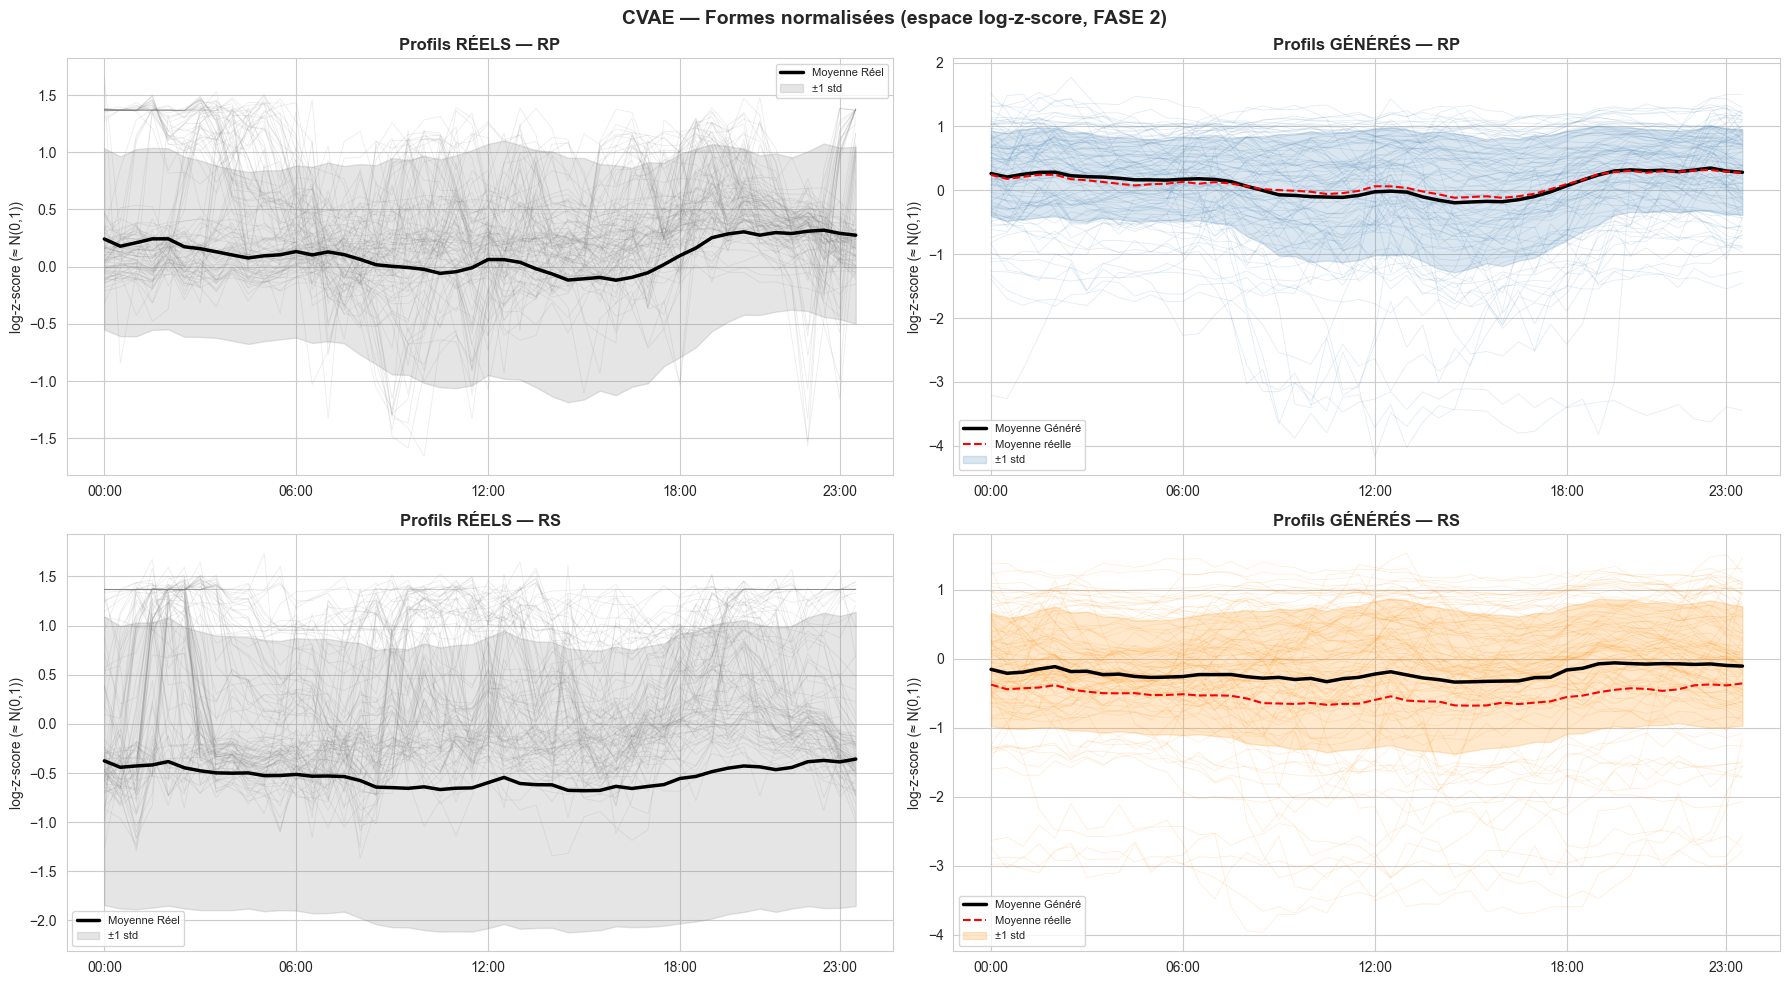

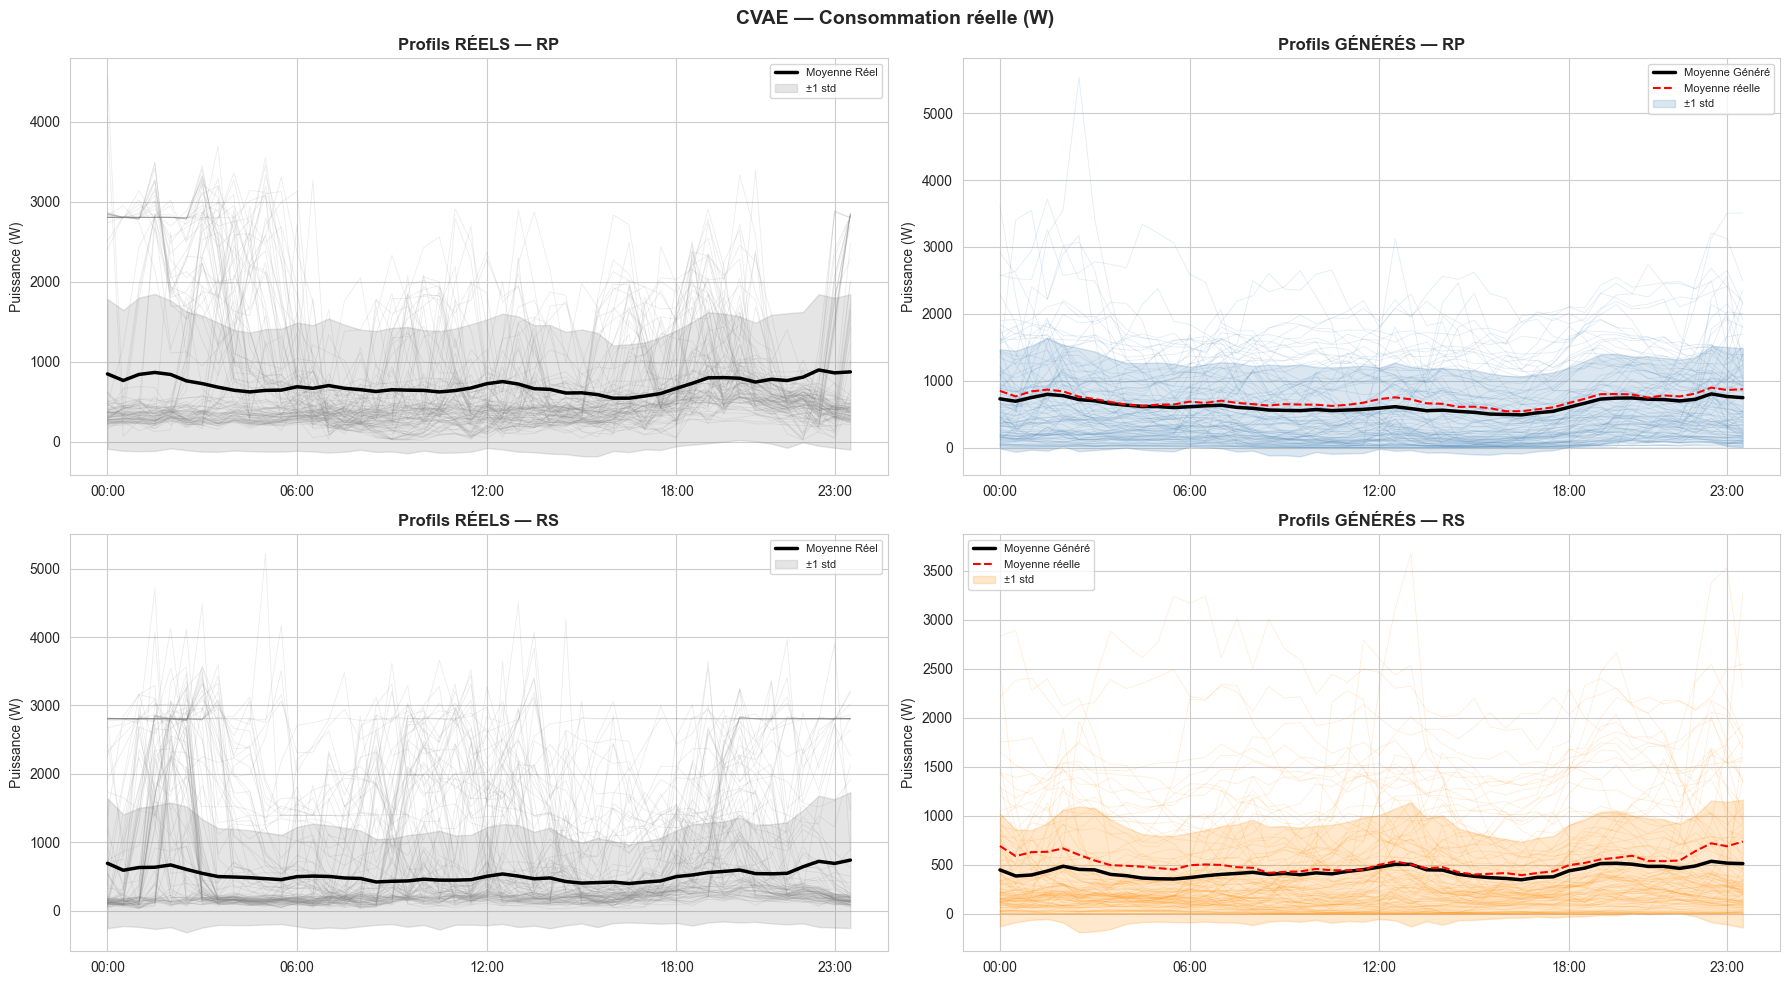

Figures sauvegardées.


In [ ]:

# Comparaison visuelle : formes normalisées + Watts réels

x_axis  = np.arange(48)
x_ticks = [0, 6, 12, 18, 23]
x_lbls  = ['00:00', '06:00', '12:00', '18:00', '23:00']

for fig_name, title, data_pairs, ylabel in [
    ('fig_11a_normalized.png', 'CVAE — Formes normalisées (espace log-z-score, PHASE 2)',
     [('RP', real_rp, gen_rp, 'steelblue'), ('RS', real_rs, gen_rs, 'darkorange')],
     'log-z-score (≈ N(0,1))'),
    ('fig_11b_watts.png', 'CVAE — Consommation réelle (W)',
     [('RP', real_rp_w, gen_rp_w, 'steelblue'), ('RS', real_rs_w, gen_rs_w, 'darkorange')],
     'Puissance (W)'),
]:
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    for row, (label, real, gen, color) in enumerate(data_pairs):
        for col, (tag, d, lbl) in enumerate([('RÉELS', real, 'Réel'), ('GÉNÉRÉS', gen, 'Généré')]):
            ax = axes[row, col]
            ax.plot(d[:100].T, color='grey' if col == 0 else color, alpha=0.15, linewidth=0.6)
            ax.plot(d.mean(axis=0), color='black', linewidth=2.5, label=f'Moyenne {lbl}')
            if col == 1:
                ax.plot(real.mean(axis=0), color='red', linewidth=1.5, linestyle='--',
                        label='Moyenne réelle')
            ax.fill_between(
                x_axis,
                d.mean(0) - d.std(0),
                d.mean(0) + d.std(0),
                alpha=0.2, color='grey' if col == 0 else color, label='±1 std'
            )
            ax.set_title(f'Profils {tag} — {label}', fontweight='bold')
            ax.set_xticks([t * 2 for t in x_ticks])
            ax.set_xticklabels(x_lbls)
            ax.set_ylabel(ylabel)
            ax.legend(fontsize=8)
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_name, dpi=150, bbox_inches='tight')
    plt.show()

print('Figures sauvegardées.')


## 6. Évaluation de la similarité statistique (test KS)

KS en log-z-score (formes + amplitude relative) :
  RP : 0.0796  |  RS : 0.1518  (objectif < 0.10)
KS sur Watts réels :
  RP : 0.0796  |  RS : 0.1518  (objectif < 0.15)


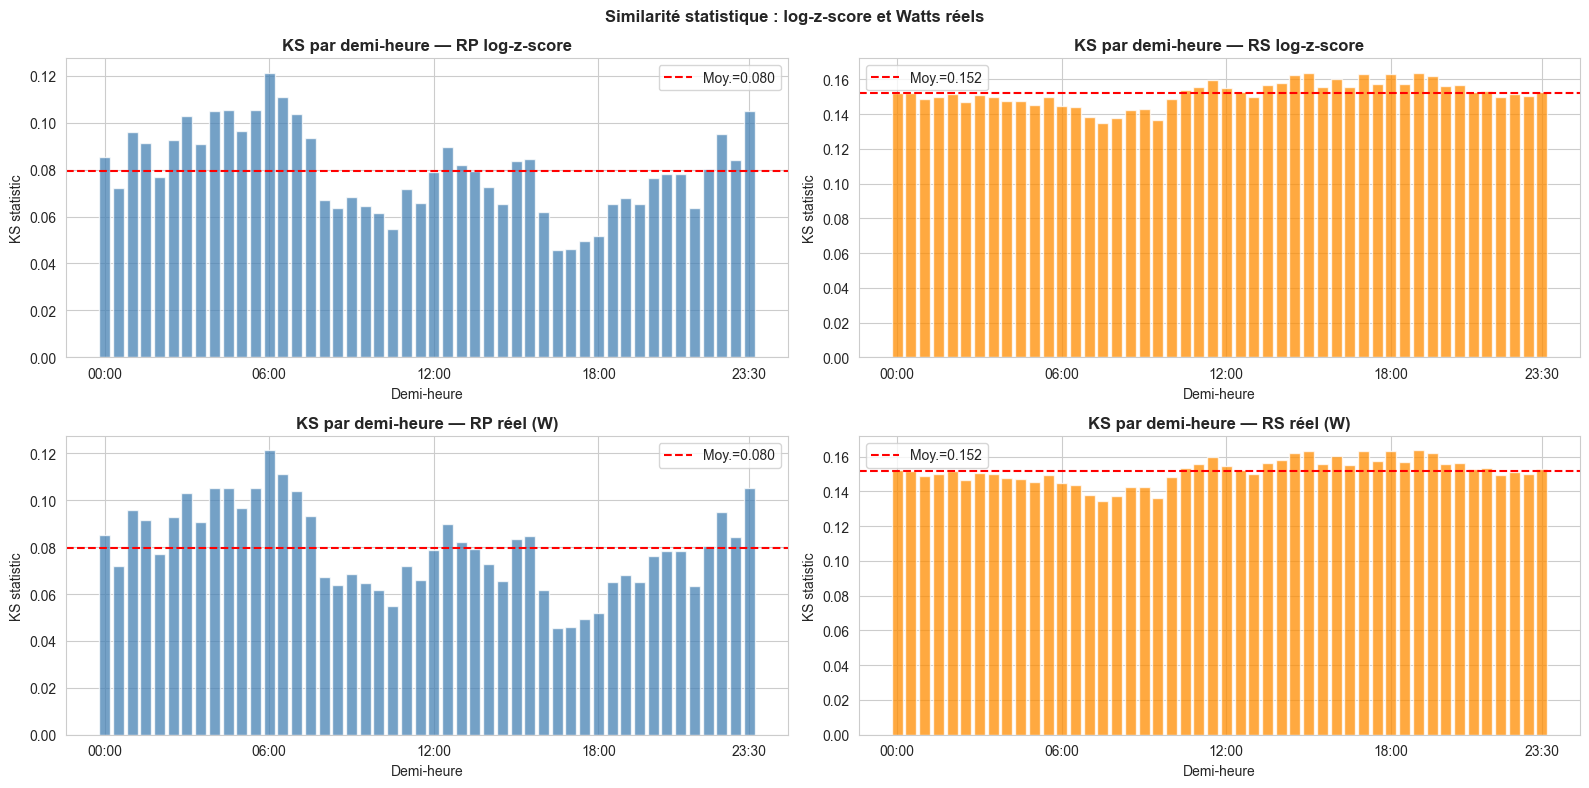

In [ ]:

# Test KS : formes normalisées (log-z-score) ET courbes en Watts (PHASE 2)

# Test sur formes normalisées (z-score) → évalue si le CVAE reproduit la
# structure temporelle ET l\'amplitude relative (puisque c\'est tout dans le
# même espace z-score global, pas un min-max par profil).
#
# Test sur Watts → évalue si la dénormalisation log+z-score est correcte.
#
# le truc de "normaliser gen à max=1" pour la comparaison disparaît,
# real et gen sont déjà tous deux dans le même espace z-score N(0,1).

ks_norm_rp, ks_norm_rs = [], []
ks_real_rp, ks_real_rs = [], []

for hh in range(48):
    ks_norm_rp.append(ks_2samp(real_rp[:, hh],   gen_rp[:, hh])[0])
    ks_norm_rs.append(ks_2samp(real_rs[:, hh],   gen_rs[:, hh])[0])
    ks_real_rp.append(ks_2samp(real_rp_w[:, hh], gen_rp_w[:, hh])[0])
    ks_real_rs.append(ks_2samp(real_rs_w[:, hh], gen_rs_w[:, hh])[0])

print('KS en log-z-score (formes + amplitude relative) :')
print(f'  RP : {np.mean(ks_norm_rp):.4f}  |  RS : {np.mean(ks_norm_rs):.4f}  (objectif < 0.10)')
print('KS sur Watts réels :')
print(f'  RP : {np.mean(ks_real_rp):.4f}  |  RS : {np.mean(ks_real_rs):.4f}  (objectif < 0.15)')

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
pairs = [
    (axes[0, 0], ks_norm_rp, 'RP log-z-score', 'steelblue'),
    (axes[0, 1], ks_norm_rs, 'RS log-z-score', 'darkorange'),
    (axes[1, 0], ks_real_rp, 'RP réel (W)',    'steelblue'),
    (axes[1, 1], ks_real_rs, 'RS réel (W)',    'darkorange'),
]
for ax, ks, label, color in pairs:
    ax.bar(range(48), ks, color=color, alpha=0.75)
    ax.axhline(np.mean(ks), color='red', linestyle='--', label=f'Moy.={np.mean(ks):.3f}')
    ax.set_title(f'KS par demi-heure — {label}', fontweight='bold')
    ax.set_xlabel('Demi-heure')
    ax.set_ylabel('KS statistic')
    ax.set_xticks([0, 12, 24, 36, 47])
    ax.set_xticklabels(['00:00', '06:00', '12:00', '18:00', '23:30'])
    ax.legend()
plt.suptitle('Similarité statistique : log-z-score et Watts réels', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_ks_similarity.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Validation agrégée — cohérence avec NB03

**Lien NB03 ↔ NB04 :** NB03 modélise la série agrégée des ~428 clients RP. NB04 génère des profils individuels. Si le CVAE est correct, la **somme de 428 profils RP synthétiques** (kWh) doit approximer statistiquement le **profil moyen agrégé réel** calculé depuis les données brutes.

Clients RP estimés : ~428


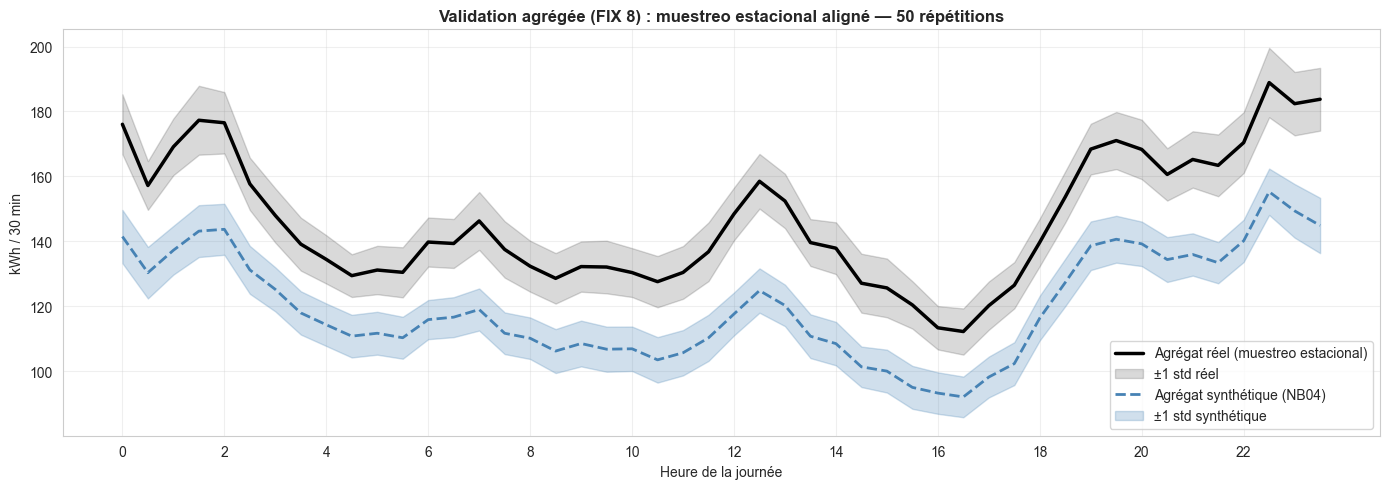


Erreurs point à point (agrégat réel vs synthétique, muestreo aligné) :
  MAE  = 26.6494 kWh / 30 min
  RMSE = 27.0601 kWh / 30 min
  MAPE = 18.15 %
  MAE / max(réel) = 14.1 % du pic

  Variabilité naturelle du réel (std moyen) :
  → std réel   = 8.2635 kWh/30min
  → std synth  = 6.8902 kWh/30min
  → Un bon modèle doit avoir std_synth ≈ std_réel.


In [ ]:

# Validation agrégée : somme de N_RP_CLIENTS profils synthétiques vs réel

# alignement de l'échantillonnage saisonnier entre réel et synthétique.
# ─────────────────────────────────────────────────────────────────────────────
# Problème précédent :
#   real_agg = mean(TOUS les profils RP) × N_RP_CLIENTS
#            → moyenne sur toutes les saisons avec poids implicites
#   synth_agg = somme de N_RP_CLIENTS profils avec saison tirée selon season_probs_rp
#            → poids saisonniers explicites (potentiellement différents)
#   Si les amplitudes varient beaucoup selon la saison (hiver >> été), même un
#   petit écart de pondération saisonnière crée un biais d'échelle important.
#
# Solution : construire le profil réel agrégé avec le MÊME processus
# d'échantillonnage saisonnier que le synthétique.
#   Pour chaque répétition k :
#     1. Tirer N_RP_CLIENTS saisons selon season_probs_rp
#     2. Pour chaque saison tirée, échantillonner UN profil réel RP de cette saison
#     3. Sommer les N_RP_CLIENTS profils réels → agrégat réel k
#   On compare ensuite les distributions des agrégats réels vs synthétiques.
#   Cette comparaison est strictement équivalente et élimine le biais.

N_RP_CLIENTS = int((y_cond == 0).sum() / daily_profiles['date'].nunique())
print(f'Clients RP estimés : ~{N_RP_CLIENTS}')

# Index des profils réels RP par saison (pour le tirage aléatoire)
real_rp_idx_by_season = {
    s: np.where((y_cond == 0) & (season_arr == s))[0]
    for s in SEASONS
}

K_REPEATS = 50
real_aggs  = []   # agrégats réels avec même échantillonnage saisonnier
synth_aggs = []

rng_val = np.random.default_rng(seed=RANDOM_STATE + 1)

for k in range(K_REPEATS):
    # Tirage des saisons (identique pour réel ET synthétique)
    seasons_k = rng_val.choice(SEASONS, size=N_RP_CLIENTS, p=season_probs_rp)

    # Agrégat RÉEL : un profil réel RP par saison tirée 
    real_k_w = np.zeros((N_RP_CLIENTS, 48), dtype=np.float32)
    for i, s in enumerate(seasons_k):
        idx_s = rng_val.choice(real_rp_idx_by_season[s])
        real_k_w[i] = X_raw[idx_s]     # profil réel en Watts
    real_aggs.append(real_k_w.sum(axis=0) * 0.5 / 1000)   # kWh

    # Agrégat SYNTHÉTIQUE : N_RP_CLIENTS profils générés (PHASE 2)
    # generate_class tire les saisons selon la distribution naturelle de RP.
    # denormalize(x_log_zscore) renvoie directement les Watts.
    gen_k, _   = generate_class(cvae, label=0, n_samples=N_RP_CLIENTS)
    gen_k_w    = denormalize(gen_k)
    synth_aggs.append(gen_k_w.sum(axis=0) * 0.5 / 1000)   # kWh

real_agg_mean  = np.mean(real_aggs,  axis=0)
real_agg_std   = np.std(real_aggs,   axis=0)
synth_agg_mean = np.mean(synth_aggs, axis=0)
synth_agg_std  = np.std(synth_aggs,  axis=0)

#  Comparaison visuelle 
hh_axis = np.arange(48) * 0.5
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hh_axis, real_agg_mean, 'k-', linewidth=2.5, label='Agrégat réel (échantillonnage saisonnier)')
ax.fill_between(hh_axis, real_agg_mean - real_agg_std, real_agg_mean + real_agg_std,
                alpha=0.15, color='black', label='±1 std réel')
ax.plot(hh_axis, synth_agg_mean, '--', color='steelblue', linewidth=2,
        label='Agrégat synthétique (NB04)')
ax.fill_between(hh_axis, synth_agg_mean - synth_agg_std, synth_agg_mean + synth_agg_std,
                alpha=0.25, color='steelblue', label='±1 std synthétique')
ax.set_xlabel('Heure de la journée')
ax.set_ylabel('kWh / 30 min')
ax.set_xticks(range(0, 24, 2))
ax.set_title(f'Validation agrégée ( 8) : échantillonnage saisonnier aligné — {K_REPEATS} répétitions',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_15_aggregate_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# Métriques point à point 
mae_agg  = np.mean(np.abs(real_agg_mean - synth_agg_mean))
rmse_agg = np.sqrt(np.mean((real_agg_mean - synth_agg_mean) ** 2))
mape_agg = np.mean(
    np.abs((real_agg_mean - synth_agg_mean) / np.clip(real_agg_mean, 1e-8, None))
) * 100

print(f'\nErreurs point à point (agrégat réel vs synthétique, échantillonnage aligné) :')
print(f'  MAE  = {mae_agg:.4f} kWh / 30 min')
print(f'  RMSE = {rmse_agg:.4f} kWh / 30 min')
print(f'  MAPE = {mape_agg:.2f} %')
print(f'  MAE / max(réel) = {mae_agg / real_agg_mean.max() * 100:.1f} % du pic')
print()
print('  Variabilité naturelle du réel (std moyen) :')
print(f'  → std réel   = {real_agg_std.mean():.4f} kWh/30min')
print(f'  → std synth  = {synth_agg_std.mean():.4f} kWh/30min')
print(f'  → Un bon modèle doit avoir std_synth ≈ std_réel.')


## 8. Erreur de reconstruction et espace latent

MSE reconstruction (test) :
  Moyenne : 0.14474
  Médiane : 0.11761
  P95     : 0.35042


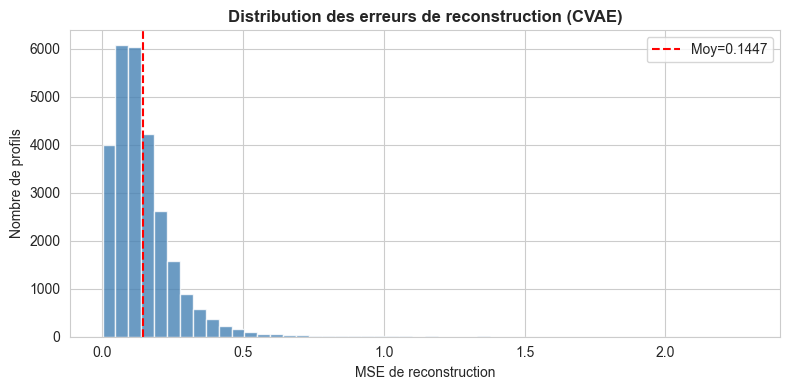

In [ ]:

# Distribution des erreurs de reconstruction (sur le jeu de test)

cvae.eval()
recon_errors = []
with torch.no_grad():
    for xb, cb in test_dl:
        xb, cb     = xb.to(device), cb.to(device)
        xr, _, _   = cvae(xb, cb)
        err        = nn.functional.mse_loss(xr, xb, reduction='none').mean(dim=1)
        recon_errors.extend(err.cpu().numpy())

recon_errors = np.array(recon_errors)
print(f'MSE reconstruction (test) :')
print(f'  Moyenne : {recon_errors.mean():.5f}')
print(f'  Médiane : {np.median(recon_errors):.5f}')
print(f'  P95     : {np.percentile(recon_errors, 95):.5f}')

plt.figure(figsize=(8, 4))
plt.hist(recon_errors, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(recon_errors.mean(), color='red', linestyle='--',
            label=f'Moy={recon_errors.mean():.4f}')
plt.xlabel('MSE de reconstruction')
plt.ylabel('Nombre de profils')
plt.title('Distribution des erreurs de reconstruction (CVAE)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('fig_13_recon_error.png', dpi=150, bbox_inches='tight')
plt.show()


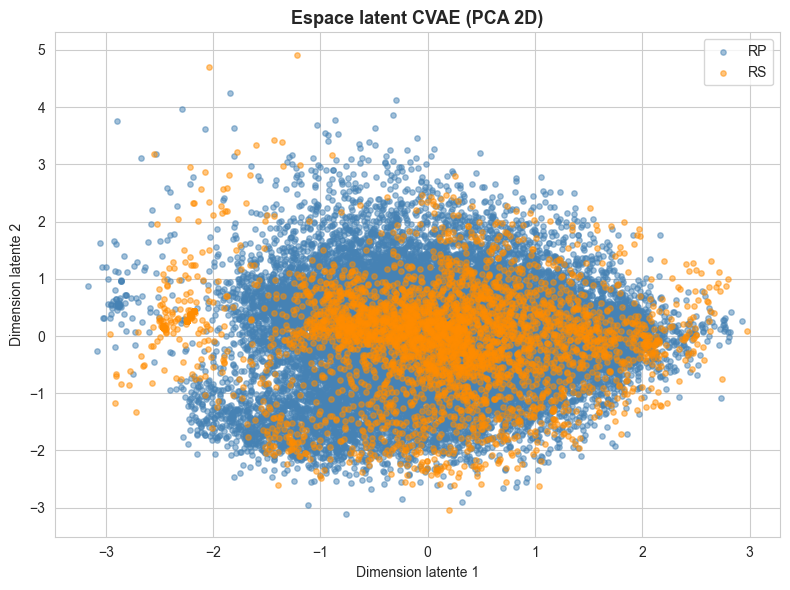


RÉSUMÉ FINAL — CVAE v2
  Hyperparamètres     : {'latent_dim': 16, 'beta': 0.2}
  KS normalisé RP/RS  : 0.0796 / 0.1518
  KS Watts     RP/RS  : 0.0796 / 0.1518
  MAE agrégat         : 26.6494 kWh/30min
  MSE reconstruction  : 0.14474
  Source modèle       : checkpoint (cvae_checkpoint.pt)


In [ ]:

# Visualisation de l'espace latent — PCA 2D

cvae.eval()
all_mu = []
with torch.no_grad():
    for xb, cb in test_dl:
        xb, cb = xb.to(device), cb.to(device)
        mu, _  = cvae.encoder(xb, cb)
        all_mu.append(mu.cpu().numpy())

Z   = np.vstack(all_mu)
Z2d = skPCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Z)

plt.figure(figsize=(8, 6))
for lbl, name, color in [(0, 'RP', 'steelblue'), (1, 'RS', 'darkorange')]:
    mask = y_te.astype(int) == lbl
    plt.scatter(Z2d[mask, 0], Z2d[mask, 1],
                label=name, alpha=0.5, s=15, color=color)
plt.title('Espace latent CVAE (PCA 2D)', fontsize=13, fontweight='bold')
plt.xlabel('Dimension latente 1')
plt.ylabel('Dimension latente 2')
plt.legend()
plt.tight_layout()
plt.savefig('fig_14_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()

#  Résumé final
print('\n' + '='*55)
print('RÉSUMÉ FINAL — CVAE v2')
print('='*55)
print(f'  Hyperparamètres     : {best_params_cvae}')
print(f'  KS normalisé RP/RS  : {np.mean(ks_norm_rp):.4f} / {np.mean(ks_norm_rs):.4f}')
print(f'  KS Watts     RP/RS  : {np.mean(ks_real_rp):.4f} / {np.mean(ks_real_rs):.4f}')
print(f'  MAE agrégat         : {mae_agg:.4f} kWh/30min')
print(f'  MSE reconstruction  : {recon_errors.mean():.5f}')

# Info sur la source du modèle
import os as _os
src = "checkpoint (cvae_checkpoint.pt)" if _os.path.exists('cvae_checkpoint.pt') else "mémoire"
print(f'  Source modèle       : {src}')


## 9. Évaluation visuelle approfondie — comparaisons individuelles et indicateurs

Les sections 5–8 ont validé le CVAE par des métriques agrégées (KS, MAE agrégat, MSE de reconstruction).
On ajoute ici une **évaluation visuelle complémentaire** inspirée des bonnes pratiques de validation
des modèles génératifs (notamment des cGAN) :

1. **Comparaison individuelle** : courbes réelles et générées tracées côte à côte (un exemple par graphique)
   pour évaluer qualitativement le réalisme et la diversité.
2. **Indicateurs physiques** : distributions de l'énergie journalière, puissance max, puissance moyenne
   et facteur de charge — vérifie la plausibilité physique des courbes.
3. **ACP conjointe** : projection des courbes réelles ET générées dans le même plan 2D pour vérifier
   le recouvrement des supports (détection de mode collapse).
4. **MAE sur profil moyen** : métrique scalaire complémentaire au KS, facile à communiquer.
5. **Export CSV** : sauvegarde des courbes synthétiques pour usage en aval (dashboard, rapport).


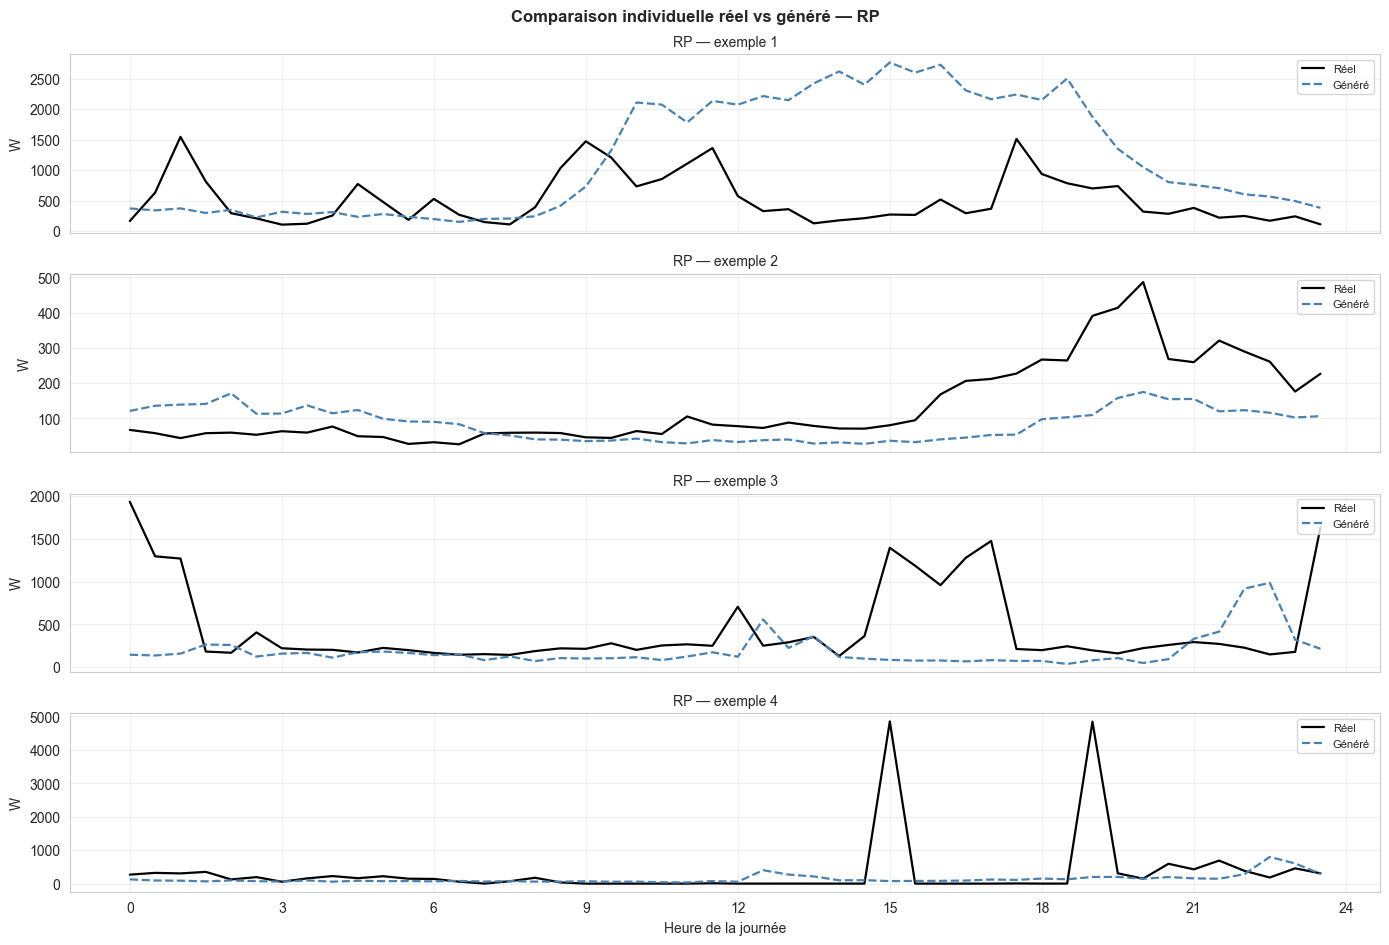

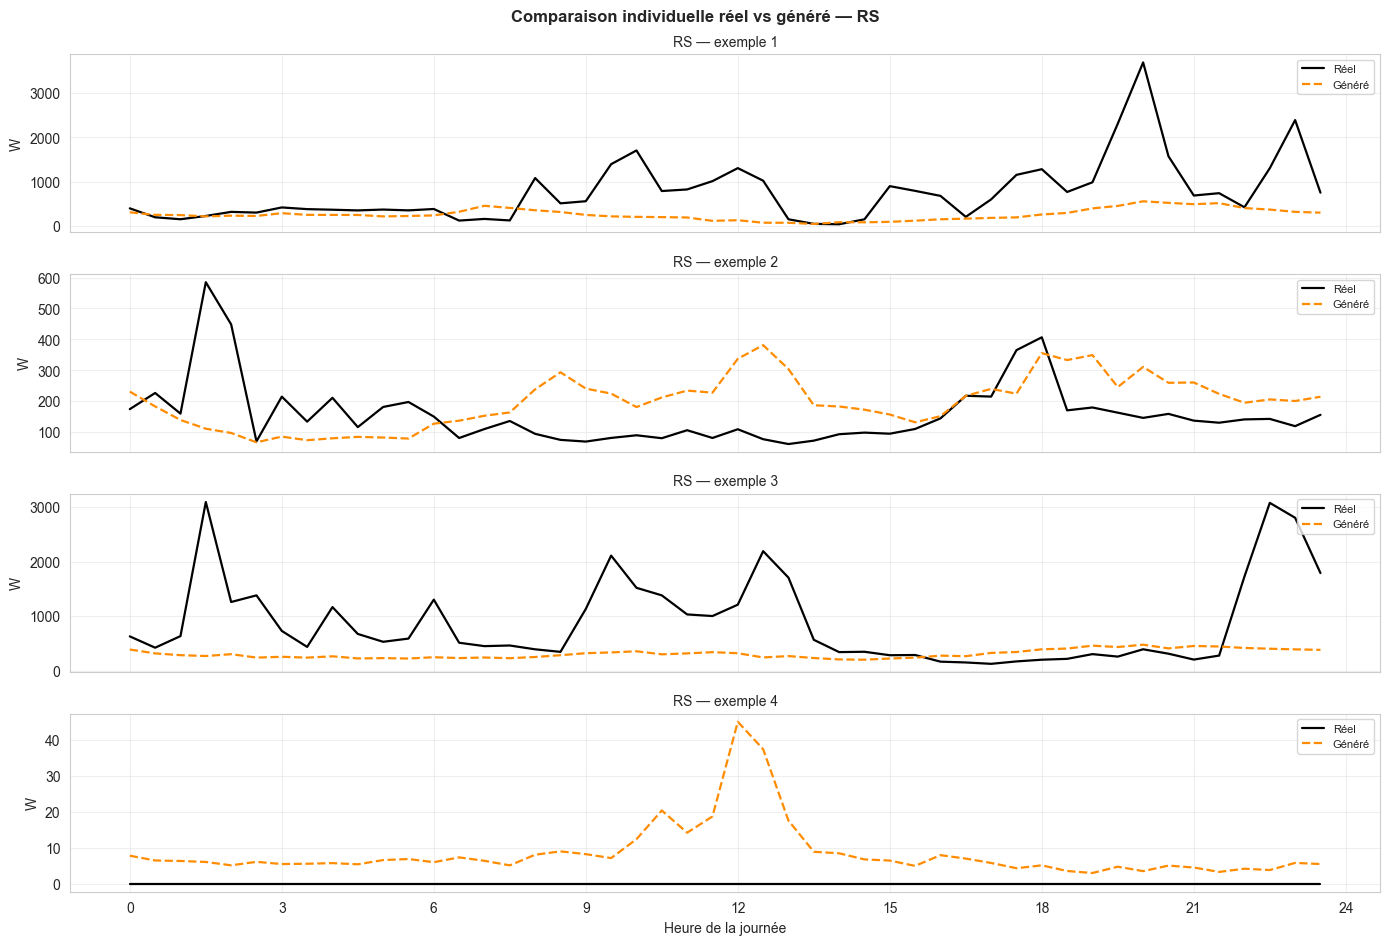

In [ ]:

# 9.1 — Courbes individuelles : réel vs généré, côte à côte

# Avantage par rapport à la section 5 (moyennes ± std de 100 profils superposés) :
# permet d'évaluer qualitativement la diversité et le réalisme de chaque
# échantillon généré, sans masquage par la moyenne.

N_EXAMPLES = 4
rng_viz = np.random.default_rng(RANDOM_STATE)


def plot_individual_real_vs_generated(label_name, real_w, gen_w, color):
    idx_real = rng_viz.choice(len(real_w), size=N_EXAMPLES, replace=False)
    idx_gen  = rng_viz.choice(len(gen_w),  size=N_EXAMPLES, replace=False)
    fig, axes = plt.subplots(N_EXAMPLES, 1, figsize=(14, 2.4 * N_EXAMPLES), sharex=True)
    for i, ax in enumerate(axes):
        ax.plot(np.arange(48) * 0.5, real_w[idx_real[i]],
                color='black', linewidth=1.6, label='Réel')
        ax.plot(np.arange(48) * 0.5, gen_w[idx_gen[i]],
                color=color, linewidth=1.6, linestyle='--', label='Généré')
        ax.set_ylabel('W')
        ax.set_title(f'{label_name} — exemple {i + 1}', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)
    axes[-1].set_xlabel('Heure de la journée')
    axes[-1].set_xticks(range(0, 25, 3))
    plt.suptitle(f'Comparaison individuelle réel vs généré — {label_name}',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'fig_16_individual_{label_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_individual_real_vs_generated('RP', real_rp_w, gen_rp_w, 'steelblue')
plot_individual_real_vs_generated('RS', real_rs_w, gen_rs_w, 'darkorange')


### 9.2 — Distribution des indicateurs physiques

Quatre indicateurs métier permettent de vérifier que les courbes synthétiques sont **physiquement plausibles** :

- **Énergie journalière** (kWh) : intégrale de la courbe — cohérence avec la consommation typique.
- **Puissance max** (W) : pic du jour — pertinent pour le dimensionnement réseau.
- **Puissance moyenne** (W) : niveau global de consommation.
- **Facteur de charge** = P_mean / P_max ∈ [0, 1] : indicateur de **régularité** du profil.
  Proche de 1 = consommation constante, proche de 0 = pics ponctuels. Un RS a typiquement un facteur
  de charge plus élevé qu'un RP.

Si le modèle est correct, les histogrammes des courbes générées doivent recouvrir ceux des courbes réelles.


=== RP ===


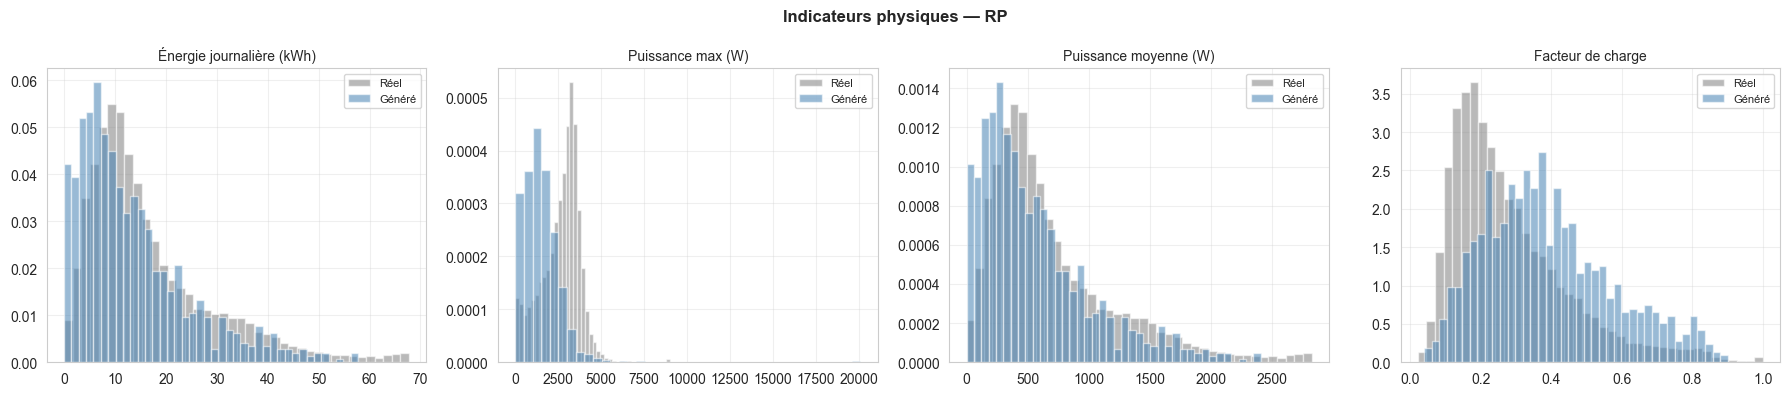

  indicator   real_mean    gen_mean      gap_%
 energy_kwh   16.900000   13.441000 -20.466999
    p_max_w 2655.580078 1478.010986 -44.342999
   p_mean_w  704.177979  560.054016 -20.466999
load_factor    0.280000    0.390000  39.148998

=== RS ===


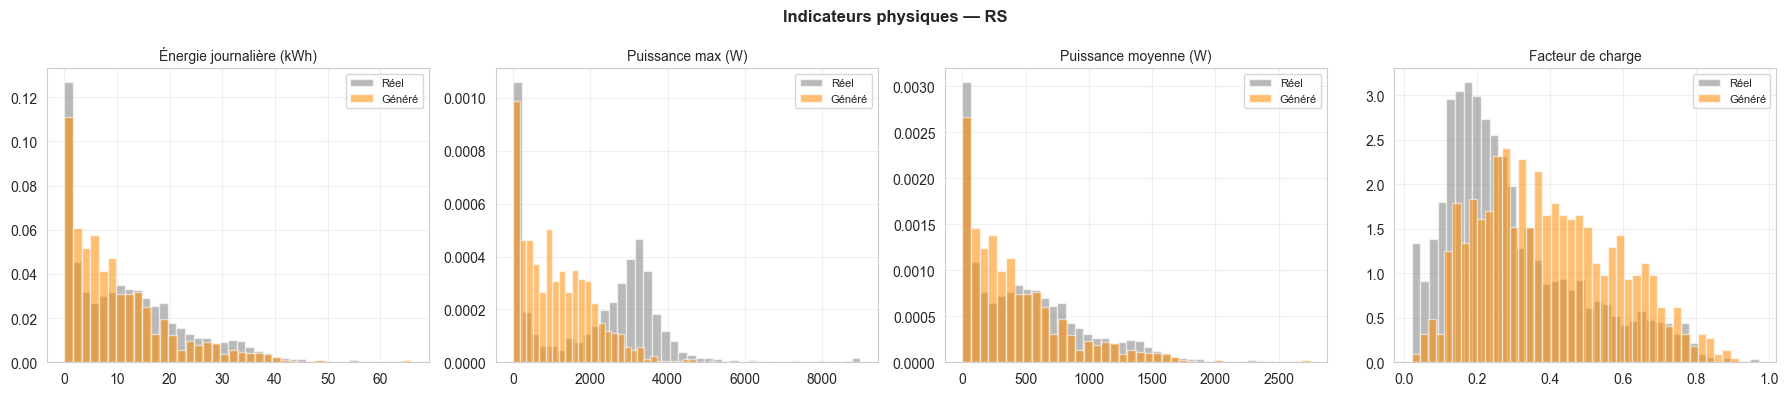

  indicator   real_mean    gen_mean      gap_%
 energy_kwh   12.411000   10.214000 -17.701000
    p_max_w 2136.083008 1145.593994 -46.368999
   p_mean_w  517.125000  425.588989 -17.701000
load_factor    0.292000    0.394000  34.845001


In [ ]:

# 9.2 — Distribution des indicateurs physiques

# Pour des histogrammes lisibles, on génère 1000 profils par classe.

N_LARGE = 1000

gen_rp_large, _    = generate_class(cvae, label=0, n_samples=N_LARGE)   # PHASE 2
gen_rs_large, _    = generate_class(cvae, label=1, n_samples=N_LARGE)
gen_rp_large_w     = denormalize(gen_rp_large)                                # PHASE 2
gen_rs_large_w     = denormalize(gen_rs_large)


def daily_indicators(X_w):
    """Calcule 4 indicateurs métier pour chaque profil journalier (48 pas)."""
    energy_kwh  = X_w.sum(axis=1) * 0.5 / 1000
    p_max       = X_w.max(axis=1)
    p_mean      = X_w.mean(axis=1)
    load_factor = np.where(p_max > 0, p_mean / p_max, np.nan)
    return pd.DataFrame({
        'energy_kwh':  energy_kwh,
        'p_max_w':     p_max,
        'p_mean_w':    p_mean,
        'load_factor': load_factor,
    })


def plot_indicators(label_name, real_w, gen_w, color):
    ind_real = daily_indicators(real_w)
    ind_gen  = daily_indicators(gen_w)
    cols   = ['energy_kwh', 'p_max_w', 'p_mean_w', 'load_factor']
    titles = ['Énergie journalière (kWh)', 'Puissance max (W)',
              'Puissance moyenne (W)',     'Facteur de charge']
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    rows = []
    for ax, c, title in zip(axes, cols, titles):
        ax.hist(ind_real[c].dropna(), bins=40, alpha=0.55, density=True,
                color='grey', label='Réel')
        ax.hist(ind_gen[c].dropna(),  bins=40, alpha=0.55, density=True,
                color=color, label='Généré')
        ax.set_title(title, fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        gap = (ind_gen[c].mean() - ind_real[c].mean()) / ind_real[c].mean() * 100
        rows.append({'indicator': c,
                     'real_mean': ind_real[c].mean(),
                     'gen_mean':  ind_gen[c].mean(),
                     'gap_%':     gap})
    plt.suptitle(f'Indicateurs physiques — {label_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'fig_17_indicators_{label_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return pd.DataFrame(rows)


print('=== RP ===')
sum_rs = plot_indicators('RP', real_rp_w, gen_rp_large_w, 'steelblue')
print(sum_rs.round(3).to_string(index=False))
print()
print('=== RS ===')
sum_rp = plot_indicators('RS', real_rs_w, gen_rs_large_w, 'darkorange')
print(sum_rp.round(3).to_string(index=False))


### 9.3 — ACP conjointe : recouvrement des supports

L'ACP de la section 8 ne projetait que les courbes réelles dans l'espace latent du CVAE.
Ici on projette **les courbes réelles ET les courbes générées dans le même plan 2D**
(PCA calculée sur l'union des deux jeux). Si le CVAE est correct, les deux nuages doivent **se recouvrir**.

C'est une vérification visuelle simple que le générateur couvre bien le support de la distribution réelle
et **ne fait pas de mode collapse** (effondrement de la diversité — risque connu des modèles génératifs).


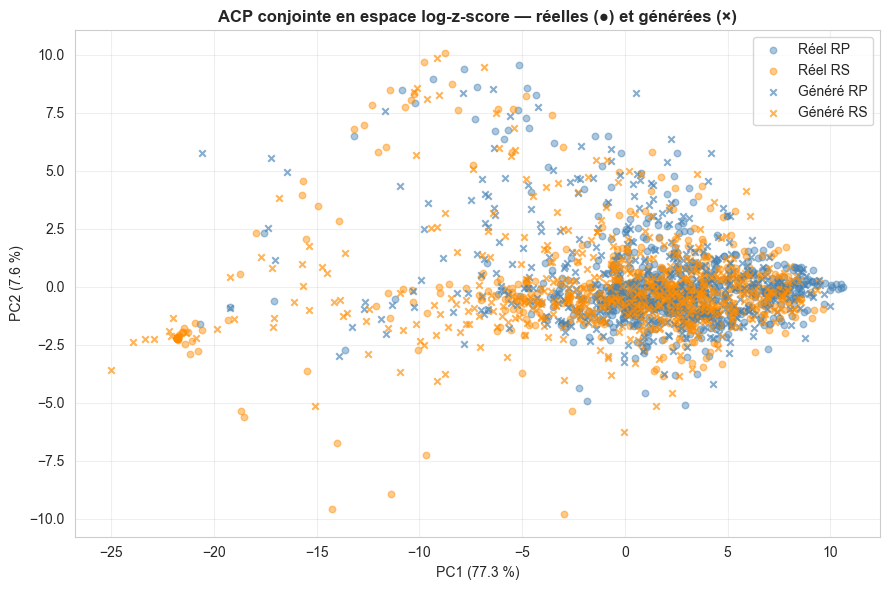

In [ ]:

# 9.3 — ACP conjointe : courbes réelles et générées (PHASE 2, espace z-score)

# En espace log-z-score, toutes les courbes sont déjà dans la même échelle
# (~N(0,1) globalement). Pas besoin de normaliser à max=1 comme avant — on
# compare directement les FORMES + AMPLITUDES dans l\'espace appris.

N_PCA = 500

# Sampling des indices avec gestion des cas où il y a moins de N_PCA profils
n_rp_avail = min(N_PCA, len(real_rp))
n_rs_avail = min(N_PCA, len(real_rs))

idx_rp = rng_viz.choice(len(real_rp), size=n_rp_avail, replace=False)
idx_rs = rng_viz.choice(len(real_rs), size=n_rs_avail, replace=False)

real_rp_pca = real_rp[idx_rp]
real_rs_pca = real_rs[idx_rs]
gen_rp_pca  = gen_rp_large[:n_rp_avail]
gen_rs_pca  = gen_rs_large[:n_rs_avail]

X_pca_all  = np.vstack([real_rp_pca, real_rs_pca, gen_rp_pca, gen_rs_pca])
labels_pca = (['Réel RP']   * n_rp_avail + ['Réel RS']   * n_rs_avail +
              ['Généré RP'] * n_rp_avail + ['Généré RS'] * n_rs_avail)

pca_joint = skPCA(n_components=2, random_state=RANDOM_STATE)
coords    = pca_joint.fit_transform(X_pca_all)

styles = {
    'Réel RP':   {'color': 'steelblue',  'marker': 'o', 'alpha': 0.45},
    'Réel RS':   {'color': 'darkorange', 'marker': 'o', 'alpha': 0.45},
    'Généré RP': {'color': 'steelblue',  'marker': 'x', 'alpha': 0.65},
    'Généré RS': {'color': 'darkorange', 'marker': 'x', 'alpha': 0.65},
}

plt.figure(figsize=(9, 6))
labels_arr = np.array(labels_pca)
for grp, st in styles.items():
    mask = labels_arr == grp
    plt.scatter(coords[mask, 0], coords[mask, 1], s=22, label=grp, **st)
plt.xlabel(f'PC1 ({pca_joint.explained_variance_ratio_[0] * 100:.1f} %)')
plt.ylabel(f'PC2 ({pca_joint.explained_variance_ratio_[1] * 100:.1f} %)')
plt.title('ACP conjointe en espace log-z-score — réelles (●) et générées (×)',
          fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('fig_18_pca_real_generated.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.4 — MAE sur le profil moyen

Métrique scalaire simple complémentaire au KS : la **MAE entre profil moyen réel et profil moyen généré**.
Une MAE faible signifie que le générateur reproduit en moyenne la forme journalière. Plus facile à
communiquer qu'un score KS dans un rapport adressé à un public non technique.


MAE entre profil moyen réel et profil moyen généré :
  RP (normalisé)  : 0.1127
  RS (normalisé)  : 0.2229
  RP (Watts)      : 144.1 W
  RS (Watts)      : 91.5 W


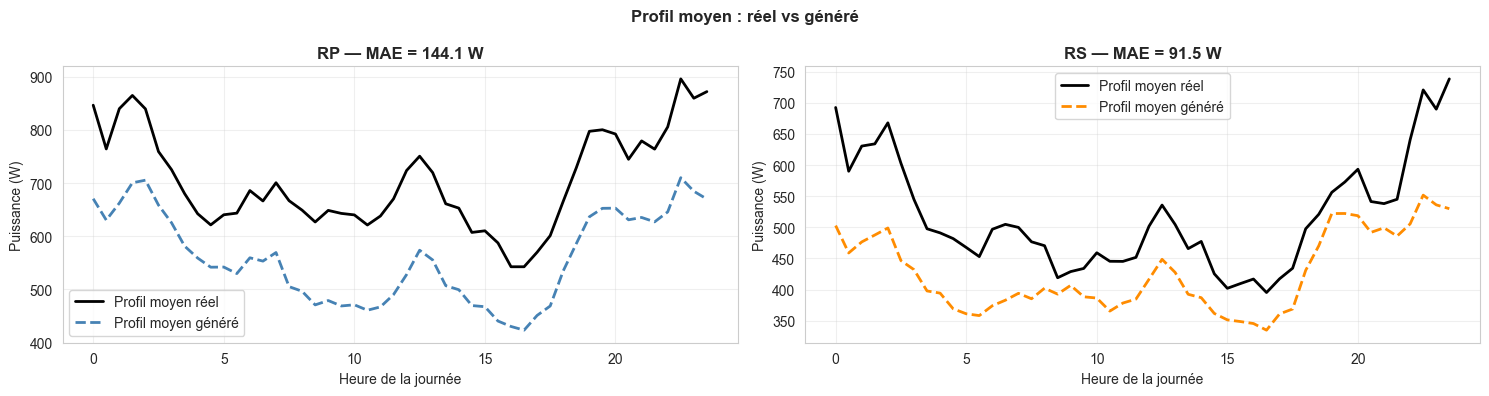

In [ ]:

# 9.4 — MAE sur les profils moyens (formes normalisées et Watts)


def mae_mean_profile(real, gen):
    """MAE entre le profil moyen réel et le profil moyen généré (par demi-heure)."""
    return float(np.mean(np.abs(real.mean(axis=0) - gen.mean(axis=0))))


mae_rp_norm = mae_mean_profile(real_rp,   gen_rp_large)
mae_rs_norm = mae_mean_profile(real_rs,   gen_rs_large)
mae_rp_w    = mae_mean_profile(real_rp_w, gen_rp_large_w)
mae_rs_w    = mae_mean_profile(real_rs_w, gen_rs_large_w)

print('MAE entre profil moyen réel et profil moyen généré :')
print(f'  RP (normalisé)  : {mae_rp_norm:.4f}')
print(f'  RS (normalisé)  : {mae_rs_norm:.4f}')
print(f'  RP (Watts)      : {mae_rp_w:.1f} W')
print(f'  RS (Watts)      : {mae_rs_w:.1f} W')

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, real, gen, label, color, mae in [
    (axes[0], real_rp_w, gen_rp_large_w, 'RP', 'steelblue',  mae_rp_w),
    (axes[1], real_rs_w, gen_rs_large_w, 'RS', 'darkorange', mae_rs_w),
]:
    ax.plot(np.arange(48) * 0.5, real.mean(axis=0),
            color='black', linewidth=2, label='Profil moyen réel')
    ax.plot(np.arange(48) * 0.5, gen.mean(axis=0),
            color=color,   linewidth=2, linestyle='--', label='Profil moyen généré')
    ax.set_xlabel('Heure de la journée')
    ax.set_ylabel('Puissance (W)')
    ax.set_title(f'{label} — MAE = {mae:.1f} W', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle('Profil moyen : réel vs généré', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_19_mean_profile.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.5 — Export des courbes générées

Sauvegarde des courbes synthétiques en CSV au format long (une ligne par demi-heure), exploitable
directement dans le dashboard ou pour des analyses ultérieures (rapport, partage, augmentation de données).


In [ ]:

# 9.5 — Export CSV des courbes générées

# Format long : une ligne par (sample_id, demi-heure).
# Utilisable dans le dashboard ou pour des analyses ultérieures.

N_EXPORT = 200
rows = []

for label_name, gen_w_arr, seasons_arr in [
    ('RP', gen_rp_w, seasons_rp),
    ('RS', gen_rs_w, seasons_rs),
]:
    n_avail = min(N_EXPORT, len(gen_w_arr))
    for i in range(n_avail):
        rows.append(pd.DataFrame({
            'sample_id':       f'{label_name}_{i:04d}',
            'label':           label_name,
            'season':          seasons_arr[i],
            'hh_index':        np.arange(48),
            'time_h':          np.arange(48) * 0.5,
            'puissance_w':     gen_w_arr[i],
            'energy_kwh_step': gen_w_arr[i] * 0.5 / 1000,
        }))

generated_df = pd.concat(rows, ignore_index=True)
generated_df.to_csv('courbes_generees_cvae.csv', index=False)

print(f'Exporté : courbes_generees_cvae.csv  ({len(generated_df):,} lignes)')
print()
print(generated_df.head())


Exporté : courbes_generees_cvae.csv  (19,200 lignes)

  sample_id label  season  hh_index  time_h  puissance_w  energy_kwh_step
0   RP_0000    RP  winter         0     0.0   551.388123         0.275694
1   RP_0000    RP  winter         1     0.5   293.720947         0.146860
2   RP_0000    RP  winter         2     1.0   194.640167         0.097320
3   RP_0000    RP  winter         3     1.5   205.424576         0.102712
4   RP_0000    RP  winter         4     2.0   180.335052         0.090168


### Récapitulatif des évaluations du CVAE

| Aspect évalué              | Section | Métrique principale            |
|----------------------------|---------|--------------------------------|
| Reconstruction             | 8       | MSE moyenne                    |
| Forme normalisée           | 6       | KS par demi-heure              |
| Watts (avec saisonnalité)  | 6       | KS par demi-heure              |
| Cohérence agrégée NB03↔NB04| 7       | MAE et KS sur l'agrégat        |
| Espace latent              | 8       | PCA 2D                         |
| **Réalisme individuel**    | **9.1** | **Inspection visuelle**        |
| **Plausibilité physique**  | **9.2** | **Distributions d'indicateurs**|
| **Recouvrement de support**| **9.3** | **PCA conjointe**              |
| **Profil moyen**           | **9.4** | **MAE en W**                   |
